# Earnings-Call Linguistics Alpha Signal

## Pipeline
1. **Data Acquisition** – Pull earnings call transcripts (WRDS Capital IQ), CRSP returns, Compustat, IBES analyst coverage — all from WRDS  
2. **Feature Engineering** – Extract linguistic features: non-answer rate (Gow et al. 2021), scripting score (Lee 2016), LM sentiment, Fog readability  
3. **Additional Features** – Performance-question non-answer rate, tone surprise, delta features  
4. **Universe & Panel Construction** – Merge to CRSP, apply filters, create low-analyst-coverage sub-universe  
5. **ML Prediction** – Expanding-window LightGBM predicting 30-day and 90-day forward returns  
6. **Portfolio Construction** – Quintile long/short portfolios (full universe & low-coverage sub-universe)  
7. **Factor Spanning** – FF5 alpha with Newey-West SEs  
8. **Summary & Visualization**

### References
- Gow, Larcker & Zakolyukina (2021), "Non-answers during Conference Calls"  
- Lee (2016), scripted Q&A responses  
- Loughran & McDonald (2011), financial sentiment dictionaries  
- Gunning Fog Index for readability

### Data Source
All data sourced from **WRDS** — no external API keys required:
- **Transcripts**: S&P Capital IQ (`ciq_transcripts.wrds_transcript_detail` + `ciq_transcripts.ciqtranscriptcomponent`)
- **Returns**: CRSP Monthly Stock File (`crsp.msf`)
- **Fundamentals**: Compustat Quarterly (`comp.fundq`)
- **Analyst Coverage**: IBES Summary Statistics (`ibes.statsumu_epsus`)
- **Factors**: Fama-French via WRDS (`ff.fivefactors_monthly`, `ff.factors_monthly`)

In [ ]:
##############################################################################
# SETUP – Imports & Configuration
##############################################################################
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import lightgbm as lgb
import wrds
import re
import json
import nltk
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ling_features package — actual top-level API:
#   fog(text)         → dict with 'fog', 'complex_words', 'fog_words', 'fog_sents'
#   non_answers(sents) → list of JSON match strings, or None
#   tone_count(text)  → dict of LM sentiment category counts
#   fls(sentence)     → bool (forward-looking statement)
#   word_count(text)  → int
#   sent_count(text)  → int
from ling_features import fog as lf_fog
from ling_features import non_answers as lf_non_answers
from ling_features import tone_count as lf_tone_count
from ling_features import fls as lf_fls
from ling_features import word_count as lf_word_count
from ling_features import sent_count as lf_sent_count

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

# ── Paths ──
# Set DATA_DIR to your local working directory, or override via environment variable
DATA_DIR = os.environ.get('DATA_DIR', os.path.dirname(os.path.abspath('.')))
os.makedirs(DATA_DIR, exist_ok=True)

# WRDS credentials (set WRDS_USER env var, or configure via ~/.pgpass)
WRDS_USER = os.environ.get('WRDS_USER', 'your_username')

print(f"Data directory: {DATA_DIR}")
print(f"WRDS user: {WRDS_USER}")

In [2]:
##############################################################################
# DEPENDENCIES – run once to install / download required packages & data
##############################################################################
# pandas<2.3 (wrds requirement), pyarrow 17 (compatible with both pandas 2.2 and sklearn)
%pip install "pyarrow==17.0.0" "pandas>=2.2,<2.3" ling_features nltk joblib -q

import nltk
nltk.download('cmudict', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
print("Dependencies ready — RESTART KERNEL if pyarrow was changed, then re-run from Setup cell.")

Note: you may need to restart the kernel to use updated packages.
Dependencies ready — RESTART KERNEL if pyarrow was changed, then re-run from Setup cell.
Dependencies ready — RESTART KERNEL if pyarrow was changed, then re-run from Setup cell.


In [3]:
# Verify parquet support
import pandas as pd, pyarrow, io, numpy as np
print(f"pandas={pd.__version__}, pyarrow={pyarrow.__version__}, numpy={np.__version__}")
buf = io.BytesIO()
pd.DataFrame({'a': [1,2,3]}).to_parquet(buf)
print("✓ Parquet write OK")

pandas=2.2.3, pyarrow=17.0.0, numpy=2.3.1
✓ Parquet write OK


---
## Step 1 – Data Acquisition: Earnings Call Transcripts (WRDS Capital IQ)

**Scope**: Top 500 largest US stocks by market cap → ~500 CIQ companies via gvkey matching only (no ticker bloat).

Strategy:
1. Server-side: top-500 CRSP permnos → CCM gvkeys → CIQ companyids  
2. Pull transcript metadata + component text only for those companies  

Component types: `2 = Presenter Speech`, `3 = Question`, `4 = Answer` | Event type: `48 = Earnings Calls`

In [2]:
##############################################################################
# STEP 1a – Load Cached CIQ Transcript Data (parquets already on disk)
##############################################################################

DETAIL_CACHE = os.path.join(DATA_DIR, 'transcript_detail_top500.parquet')
META_CACHE   = os.path.join(DATA_DIR, 'transcript_meta_top500.parquet')
GVKEY_CACHE  = os.path.join(DATA_DIR, 'ciq_gvkey.parquet')
TICKER_CACHE = os.path.join(DATA_DIR, 'ciq_ticker.parquet')
TOP_N = 500

print("Loading cached data from parquets...")
transcript_meta   = pd.read_parquet(META_CACHE)
ciq_gvkey         = pd.read_parquet(GVKEY_CACHE)
ciq_ticker        = pd.read_parquet(TICKER_CACHE)

# Label component types for reference
type_map = {1: 'Pres. Operator', 2: 'Presenter Speech', 3: 'Question',
            4: 'Answer', 5: 'Pres. Section', 6: 'Q&A Section',
            7: 'Q&A Operator', 8: 'Unknown Q&A'}

print(f"  transcript_meta : {transcript_meta.shape}")
print(f"  ciq_gvkey       : {ciq_gvkey.shape}")
print(f"  ciq_ticker      : {ciq_ticker.shape}")
print(f"  Companies       : {transcript_meta['companyid'].nunique():,}")
print(f"  Transcripts     : {len(transcript_meta):,}")
print(f"  (Detail parquet will be loaded in Step 1b for assembly)")


Loading cached data from parquets...
  transcript_meta : (74029, 6)
  ciq_gvkey       : (141794, 6)
  ciq_ticker      : (248261, 5)
  Companies       : 504
  Transcripts     : 74,029
  (Detail parquet will be loaded in Step 1b for assembly)
  transcript_meta : (74029, 6)
  ciq_gvkey       : (141794, 6)
  ciq_ticker      : (248261, 5)
  Companies       : 504
  Transcripts     : 74,029
  (Detail parquet will be loaded in Step 1b for assembly)


In [3]:
##############################################################################
# STEP 1b – Assemble Transcripts (SMALL: 200 companies, 2020-2024)
##############################################################################
import time as _time, gc

TRANSCRIPT_CACHE = os.path.join(DATA_DIR, 'transcripts_assembled.parquet')

if os.path.exists(TRANSCRIPT_CACHE):
    print("Loading cached assembled transcripts...")
    transcripts_df = pd.read_parquet(TRANSCRIPT_CACHE)
else:
    t0 = _time.time()
    N_COMPANIES = 200
    START_YEAR  = '2020-01-01'

    # ── 1. Pick 200 companies with most transcripts in 2020-2024 ──
    meta_recent = transcript_meta[
        transcript_meta['mostimportantdateutc'] >= START_YEAR
    ].copy()
    top_companies = (meta_recent.groupby('companyid').size()
                     .nlargest(N_COMPANIES).index)
    meta_recent = meta_recent[meta_recent['companyid'].isin(top_companies)]
    recent_tids = set(meta_recent['transcriptid'].unique())
    print(f"Scope: {len(top_companies)} companies, {len(recent_tids):,} transcripts (2020+)")

    # ── 2. Read detail parquet in CHUNKS to avoid OOM ──
    print("Reading detail parquet in chunks...")
    import pyarrow.parquet as pq
    pf = pq.ParquetFile(DETAIL_CACHE)

    md_parts, qa_parts, q_counts = [], [], []
    for batch in pf.iter_batches(
        batch_size=200_000,
        columns=['transcriptid', 'transcriptcomponenttypeid', 'componenttext']
    ):
        chunk = batch.to_pandas()
        # Filter immediately — keep only our transcripts + speech types
        chunk = chunk[
            chunk['transcriptid'].isin(recent_tids) &
            chunk['transcriptcomponenttypeid'].isin([2, 3, 4])
        ]
        if len(chunk) == 0:
            continue
        chunk['componenttext'] = chunk['componenttext'].fillna('')

        # Aggregate within this chunk
        md = (chunk.loc[chunk['transcriptcomponenttypeid'] == 2]
              .groupby('transcriptid')['componenttext'].agg(' '.join))
        qa = (chunk.loc[chunk['transcriptcomponenttypeid'].isin([3, 4])]
              .groupby('transcriptid')['componenttext'].agg(' '.join))
        nq = (chunk.loc[chunk['transcriptcomponenttypeid'] == 3]
              .groupby('transcriptid').size())

        if len(md) > 0: md_parts.append(md)
        if len(qa) > 0: qa_parts.append(qa)
        if len(nq) > 0: q_counts.append(nq)
        del chunk; gc.collect()

    del pf; gc.collect()

    # ── 3. Combine chunk results ──
    print("Combining chunk results...")
    md_text = pd.concat(md_parts).groupby(level=0).agg(' '.join).rename('md_text')
    qa_text = pd.concat(qa_parts).groupby(level=0).agg(' '.join).rename('qa_text')
    n_qs    = pd.concat(q_counts).groupby(level=0).sum().rename('n_questions')
    del md_parts, qa_parts, q_counts; gc.collect()

    # ── 4. Build output DataFrame ──
    transcripts_df = meta_recent[
        ['transcriptid', 'companyid', 'companyname', 'mostimportantdateutc']
    ].copy()
    transcripts_df = (
        transcripts_df
        .merge(md_text, on='transcriptid', how='left')
        .merge(qa_text, on='transcriptid', how='left')
        .merge(n_qs,    on='transcriptid', how='left')
    )
    transcripts_df['md_text']  = transcripts_df['md_text'].fillna('')
    transcripts_df['qa_text']  = transcripts_df['qa_text'].fillna('')
    transcripts_df['full_text'] = transcripts_df['md_text'] + ' ' + transcripts_df['qa_text']
    transcripts_df['n_questions'] = transcripts_df['n_questions'].fillna(0).astype(int)

    # Merge ticker & gvkey
    ciq_gvkey['enddate'] = ciq_gvkey['enddate'].fillna(pd.Timestamp('2099-12-31'))
    ciq_ticker['enddate'] = ciq_ticker['enddate'].fillna(pd.Timestamp('2099-12-31'))
    gk = ciq_gvkey.sort_values('enddate').drop_duplicates('companyid', keep='last')
    tk = ciq_ticker.sort_values('enddate').drop_duplicates('companyid', keep='last')
    transcripts_df = transcripts_df.merge(tk[['companyid','ticker']], on='companyid', how='left')
    transcripts_df = transcripts_df.merge(gk[['companyid','gvkey']],  on='companyid', how='left')

    transcripts_df['date'] = transcripts_df['mostimportantdateutc']
    transcripts_df['year'] = transcripts_df['date'].dt.year
    transcripts_df['quarter'] = transcripts_df['date'].dt.quarter
    transcripts_df['transcript_length'] = transcripts_df['full_text'].str.split().str.len()
    transcripts_df = transcripts_df[transcripts_df['transcript_length'] >= 100]

    transcripts_df.to_parquet(TRANSCRIPT_CACHE)
    print(f"Done in {_time.time()-t0:.0f}s")

print(f"\nTranscripts: {len(transcripts_df):,}")
print(f"Date range:  {transcripts_df['date'].min().date()} – {transcripts_df['date'].max().date()}")
print(f"Companies:   {transcripts_df['companyid'].nunique():,}")
print(f"With gvkey:  {transcripts_df['gvkey'].notna().sum():,}")
print(f"Avg length:  {transcripts_df['transcript_length'].mean():,.0f} words")


Scope: 200 companies, 9,537 transcripts (2020+)
Reading detail parquet in chunks...
Combining chunk results...
Combining chunk results...
Done in 306s

Transcripts: 9,537
Date range:  2020-01-08 – 2025-12-19
Companies:   200
With gvkey:  9,537
Avg length:  8,562 words
Done in 306s

Transcripts: 9,537
Date range:  2020-01-08 – 2025-12-19
Companies:   200
With gvkey:  9,537
Avg length:  8,562 words


---
## Step 2 – Pull CRSP, Compustat & IBES from WRDS

In [4]:
##############################################################################
# STEP 2a – Open WRDS Connection & Pull CRSP Monthly Returns
##############################################################################
import time

CRSP_CACHE = os.path.join(DATA_DIR, 'crsp_monthly.parquet')

# ── WRDS connection (used for Steps 2a–2d + 7a) ──
for attempt in range(3):
    try:
        print(f"WRDS connection attempt {attempt+1}/3...")
        db = wrds.Connection(wrds_username=WRDS_USER)
        print("Connected!")
        break
    except Exception as e:
        print(f"  Failed: {e}")
        if attempt < 2:
            time.sleep(5*(attempt+1))
        else:
            raise

if os.path.exists(CRSP_CACHE):
    print("Loading cached CRSP data...")
    crsp = pd.read_parquet(CRSP_CACHE)
else:
    crsp_query = """
        SELECT a.permno, a.date, a.ret, a.prc, a.shrout, a.vol,
               b.siccd, b.exchcd, b.ticker, b.shrcd
        FROM crsp.msf AS a
        INNER JOIN crsp.msenames AS b
            ON a.permno = b.permno
            AND a.date >= b.namedt AND a.date <= b.nameendt
        WHERE b.shrcd IN (10, 11)
          AND a.date >= '2014-01-01'
          AND a.date <= '2025-12-31'
    """
    print("Pulling CRSP data from WRDS...")
    crsp = pd.DataFrame(db.raw_sql(crsp_query, date_cols=['date']))
    crsp.to_parquet(CRSP_CACHE)

# Market cap in millions
crsp['mktcap'] = crsp['prc'].abs() * crsp['shrout'] / 1000
crsp['date'] = crsp['date'] + pd.offsets.MonthEnd(0)

# Lag market cap
crsp = crsp.sort_values(['permno', 'date'])
crsp['mktcap_lag'] = crsp.groupby('permno')['mktcap'].shift(1)

# Exclude financials & utilities
crsp['siccd'] = pd.to_numeric(crsp['siccd'], errors='coerce')
crsp = crsp[~crsp['siccd'].between(6000, 6999) & ~crsp['siccd'].between(4900, 4999)]

# Price filter: > $5
crsp = crsp[crsp['prc'].abs() > 5]

# Forward returns
crsp['ret_fwd_1m'] = crsp.groupby('permno')['ret'].shift(-1)
r1 = crsp.groupby('permno')['ret'].shift(-1).fillna(0) + 1
r2 = crsp.groupby('permno')['ret'].shift(-2).fillna(0) + 1
r3 = crsp.groupby('permno')['ret'].shift(-3).fillna(0) + 1
crsp['ret_fwd_3m'] = r1 * r2 * r3 - 1

print(f"CRSP shape: {crsp.shape}")
print(f"Date range: {crsp['date'].min()} to {crsp['date'].max()}")
print(f"Unique permnos: {crsp['permno'].nunique():,}")


WRDS connection attempt 1/3...
Loading library list...
Loading library list...
Done
Connected!
Pulling CRSP data from WRDS...
Done
Connected!
Pulling CRSP data from WRDS...
CRSP shape: (312235, 14)
Date range: 2014-01-31 00:00:00 to 2024-12-31 00:00:00
Unique permnos: 5,254
CRSP shape: (312235, 14)
Date range: 2014-01-31 00:00:00 to 2024-12-31 00:00:00
Unique permnos: 5,254


In [5]:
##############################################################################
# STEP 2b – Compustat: Earnings Surprise (SUE)
##############################################################################

COMPUSTAT_CACHE = os.path.join(DATA_DIR, 'compustat_q.parquet')

if os.path.exists(COMPUSTAT_CACHE):
    print("Loading cached Compustat data...")
    compustat = pd.read_parquet(COMPUSTAT_CACHE)
else:
    compustat_query = """
        SELECT gvkey, datadate, fyearq, fqtr,
               epspiq, epspxq, revtq, ibq, atq, saleq
        FROM comp.fundq
        WHERE datadate >= '2012-01-01' AND datadate <= '2025-12-31'
          AND indfmt = 'INDL' AND datafmt = 'STD'
          AND popsrc = 'D' AND consol = 'C'
    """
    print("Pulling Compustat quarterly data from WRDS...")
    compustat = pd.DataFrame(db.raw_sql(compustat_query, date_cols=['datadate']))
    compustat.to_parquet(COMPUSTAT_CACHE)

compustat = compustat.sort_values(['gvkey', 'datadate'])
compustat['eps_lag4'] = compustat.groupby('gvkey')['epspiq'].shift(4)
compustat['earnings_surprise'] = compustat['epspiq'] - compustat['eps_lag4']
compustat['eps_std'] = compustat.groupby('gvkey')['epspiq'].transform(
    lambda x: x.rolling(8, min_periods=4).std()
)
compustat['sue'] = compustat['earnings_surprise'] / compustat['eps_std'].replace(0, np.nan)

print(f"Compustat shape: {compustat.shape}")
print(compustat[['gvkey','datadate','epspiq','sue']].dropna().head(5))


Pulling Compustat quarterly data from WRDS...
Compustat shape: (667815, 14)
        gvkey   datadate  epspiq       sue
48159  001004 2013-02-28    0.47 -0.556307
60132  001004 2013-05-31    0.01 -1.651368
72072  001004 2013-08-31    0.45 -0.057467
83933  001004 2013-11-30    0.51  0.358431
95653  001004 2014-02-28    0.45  -0.12276
Compustat shape: (667815, 14)
        gvkey   datadate  epspiq       sue
48159  001004 2013-02-28    0.47 -0.556307
60132  001004 2013-05-31    0.01 -1.651368
72072  001004 2013-08-31    0.45 -0.057467
83933  001004 2013-11-30    0.51  0.358431
95653  001004 2014-02-28    0.45  -0.12276


In [7]:
##############################################################################
# STEP 2c – IBES: Analyst Coverage
##############################################################################

IBES_CACHE = os.path.join(DATA_DIR, 'ibes_coverage.parquet')

if os.path.exists(IBES_CACHE):
    print("Loading cached IBES data...")
    ibes_latest = pd.read_parquet(IBES_CACHE)
else:
    ibes_query = """
        SELECT ticker, fpedats, statpers, numest, meanest, medest
        FROM ibes.statsumu_epsus
        WHERE fpedats >= '2014-01-01' AND fpedats <= '2025-12-31'
          AND fpi = '1' AND statpers >= '2014-01-01'
    """
    print("Pulling IBES data from WRDS...")
    ibes = pd.DataFrame(db.raw_sql(ibes_query, date_cols=['fpedats', 'statpers']))
    ibes = ibes.sort_values(['ticker', 'fpedats', 'statpers'])
    ibes_latest = ibes.groupby(['ticker', 'fpedats']).last().reset_index()
    ibes_latest.to_parquet(IBES_CACHE)

ibes_latest['n_analysts'] = ibes_latest['numest']
ibes_latest['low_coverage'] = (ibes_latest['n_analysts'] <= 3).astype(int)

print(f"IBES shape: {ibes_latest.shape}")
print(f"Low coverage (≤3 analysts): {ibes_latest['low_coverage'].mean():.1%}")


Pulling IBES data from WRDS...
IBES shape: (62009, 8)
Low coverage (≤3 analysts): 41.3%
IBES shape: (62009, 8)
Low coverage (≤3 analysts): 41.3%


In [8]:
##############################################################################
# STEP 2d – CRSP ↔ Compustat ↔ IBES Linking
##############################################################################

CCM_CACHE = os.path.join(DATA_DIR, 'ccm_link.parquet')
ICLINK_CACHE = os.path.join(DATA_DIR, 'iclink.parquet')

# ── CCM link table (new WRDS schema) ──
if os.path.exists(CCM_CACHE):
    ccm = pd.read_parquet(CCM_CACHE)
else:
    ccm_query = """
        SELECT gvkey, lpermno AS permno, linkdt, linkenddt, linktype, linkprim
        FROM crsp_a_ccm.ccmxpf_lnkhist
        WHERE linktype IN ('LU', 'LC') AND linkprim IN ('P', 'C')
    """
    ccm = pd.DataFrame(db.raw_sql(ccm_query, date_cols=['linkdt', 'linkenddt']))
    ccm.to_parquet(CCM_CACHE)

ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.Timestamp('2099-12-31'))
ccm_latest = ccm.sort_values('linkenddt').drop_duplicates(subset='gvkey', keep='last')
gvkey_to_permno = dict(zip(ccm_latest['gvkey'], ccm_latest['permno']))
print(f"CCM link: {len(gvkey_to_permno):,} gvkey→permno mappings")

# ── ICLINK: IBES ↔ CRSP ──
if os.path.exists(ICLINK_CACHE):
    iclink = pd.read_parquet(ICLINK_CACHE)
else:
    try:
        iclink = pd.DataFrame(db.raw_sql("""
            SELECT ticker AS ibes_ticker, permno FROM wrdsapps.iclink WHERE score <= 2
        """))
        iclink = iclink.drop_duplicates(subset=['ibes_ticker', 'permno'])
        iclink.to_parquet(ICLINK_CACHE)
    except Exception as e:
        print(f"ICLINK not available ({e}); will use ticker-based matching.")
        iclink = None

# ── CRSP ticker→permno fallback ──
crsp_tickers = crsp[['permno', 'ticker', 'date']].dropna(subset=['ticker'])
crsp_tickers = crsp_tickers.sort_values('date').drop_duplicates(subset='ticker', keep='last')
ticker_to_permno = dict(zip(crsp_tickers['ticker'], crsp_tickers['permno']))
print(f"CRSP tickers: {len(ticker_to_permno):,}")
if iclink is not None:
    print(f"ICLINK: {len(iclink):,} mappings")


CCM link: 29,163 gvkey→permno mappings
ICLINK not available ((psycopg2.errors.UndefinedTable) relation "wrdsapps.iclink" does not exist
LINE 2: ...        SELECT ticker AS ibes_ticker, permno FROM wrdsapps.i...
                                                             ^

[SQL: 
            SELECT ticker AS ibes_ticker, permno FROM wrdsapps.iclink WHERE score <= 2
        ]
(Background on this error at: https://sqlalche.me/e/20/f405)); will use ticker-based matching.
CRSP tickers: 5,729
CRSP tickers: 5,729


---
## Step 3 – Linguistic Feature Extraction

Using `ling_features` package + custom scripting score:
1. **Non-answer rate** (Gow, Larcker & Zakolyukina 2021) – `ling_features.non_answers(sents)` detects refusals, deferrals, and evasions via regex  
2. **Scripting score** (Lee 2016) – TF-IDF cosine similarity between MD and Q&A portions (custom implementation)  
3. **LM Sentiment** – `ling_features.tone_count(text)` returns Loughran-McDonald category counts  
4. **Fog Index** – `ling_features.fog(text)` returns Gunning Fog readability index  
5. **Forward-looking statements** – `ling_features.fls(sentence)` classifies each sentence

In [11]:
##############################################################################
# STEP 3a – FAST Feature Extraction (tone + scripting only — no fog/fls/non_answers)
##############################################################################

def extract_features_fast(row):
    """Fast features: LM tone counts + scripting score. ~50x faster than full."""
    out = {
        'transcriptid': row['transcriptid'],
        'ticker': row.get('ticker'),
        'gvkey': row.get('gvkey'),
        'date': row['date'],
        'year': row['year'],
        'quarter': row['quarter'],
    }
    md  = str(row.get('md_text', '') or '')[:50_000]
    qa  = str(row.get('qa_text', '') or '')[:50_000]
    full = str(row.get('full_text', '') or '')[:80_000]

    if len(full) < 200:
        return out

    # ── 1. LM Tone (fast — pure dict lookup) ──
    try:
        nw = lf_word_count(full)
        tc = lf_tone_count(full)
        pos = tc.get('positive', tc.get('Positive', 0))
        neg = tc.get('negative', tc.get('Negative', 0))
        out['tone_net'] = (pos - neg) / max(nw, 1)
        out['tone_pos_pct'] = pos / max(nw, 1)
        out['tone_neg_pct'] = neg / max(nw, 1)
        out['tone_n_words'] = nw
        # QA tone
        if len(qa) > 100:
            tc_qa = lf_tone_count(qa); nw_qa = lf_word_count(qa)
            out['qa_tone_net'] = (tc_qa.get('positive', tc_qa.get('Positive',0))
                                - tc_qa.get('negative', tc_qa.get('Negative',0))) / max(nw_qa,1)
        # MD tone
        if len(md) > 100:
            tc_md = lf_tone_count(md); nw_md = lf_word_count(md)
            out['md_tone_net'] = (tc_md.get('positive', tc_md.get('Positive',0))
                                - tc_md.get('negative', tc_md.get('Negative',0))) / max(nw_md,1)
        out['tone_gap_md_qa'] = out.get('md_tone_net', 0) - out.get('qa_tone_net', 0)
    except Exception:
        pass

    # ── 2. Scripting Score (fast — one TF-IDF fit on 2 docs) ──
    if len(md) > 200 and len(qa) > 200:
        try:
            vecs = TfidfVectorizer(max_features=2000, stop_words='english').fit_transform([md, qa])
            out['scripting_score'] = float(cosine_similarity(vecs[0:1], vecs[1:2])[0, 0])
        except Exception:
            pass

    # ── 3. Metadata ──
    out['transcript_length'] = lf_word_count(full)
    out['qa_length'] = lf_word_count(qa) if len(qa) > 10 else 0
    out['md_length'] = lf_word_count(md) if len(md) > 10 else 0
    out['qa_share'] = out['qa_length'] / max(out['transcript_length'], 1)
    out['n_questions'] = row.get('n_questions', 0)

    return out

print("Fast feature extraction defined (tone + scripting only).")


Fast feature extraction defined (tone + scripting only).


In [12]:
##############################################################################
# STEP 3b – Run FAST Feature Extraction (≤2000 transcripts, ~2 min)
##############################################################################
import time as _time, gc

FEATURES_CACHE = os.path.join(DATA_DIR, 'linguistic_features.parquet')

# Delete stale cache if it exists (from previous slow run)
if os.path.exists(FEATURES_CACHE):
    try:
        tmp = pd.read_parquet(FEATURES_CACHE)
        if 'tone_net' in tmp.columns and len(tmp) > 100:
            print("Loading cached linguistic features...")
            ling_df = tmp
        else:
            os.remove(FEATURES_CACHE)
            raise ValueError("stale cache")
    except Exception:
        ling_df = None

if 'ling_df' not in dir() or ling_df is None:
    # Subsample: random 2000 transcripts for speed
    MAX_TRANSCRIPTS = 2000
    if len(transcripts_df) > MAX_TRANSCRIPTS:
        sample_df = transcripts_df.sample(MAX_TRANSCRIPTS, random_state=42)
        print(f"Sampled {MAX_TRANSCRIPTS} of {len(transcripts_df):,} transcripts")
    else:
        sample_df = transcripts_df

    n = len(sample_df)
    print(f"Extracting FAST features from {n:,} transcripts...")
    t0 = _time.time()

    results = []
    for i, (_, row) in enumerate(sample_df.iterrows()):
        results.append(extract_features_fast(row.to_dict()))
        if (i + 1) % 500 == 0:
            el = _time.time() - t0
            print(f"  {i+1:,}/{n:,}  ({(i+1)/el:.0f}/s, ~{(n-i-1)/((i+1)/el)/60:.1f}m left)")

    ling_df = pd.DataFrame(results)
    ling_df.to_parquet(FEATURES_CACHE)
    print(f"  Done in {(_time.time()-t0):.0f}s")

    del results; gc.collect()

print(f"\nLinguistic features: {ling_df.shape}")
num_cols = ling_df.select_dtypes(include=[np.number]).columns[:8].tolist()
print(ling_df[num_cols].describe().round(3))


Loading cached linguistic features...

Linguistic features: (9537, 23)
       transcriptid      year   quarter  non_answer_rate  n_non_answers  scripting_score  tone_net  tone_pos_pct
count      9537.000  9537.000  9537.000         9537.000       9537.000         9389.000  9537.000      9537.000
mean    2633782.315  2022.105     2.454            0.015          4.848            0.365     0.008         0.016
std      541069.573     1.831     1.126            0.011          3.681            0.097     0.006         0.004
min     1887858.000  2020.000     1.000            0.000          0.000            0.029    -0.013         0.005
25%     2127441.000  2020.000     1.000            0.008          2.000            0.311     0.005         0.013
50%     2551755.000  2022.000     2.000            0.014          4.000            0.369     0.008         0.015
75%     3093423.000  2024.000     3.000            0.021          7.000            0.426     0.012         0.018
max     3629794.000  2025

---
## Step 4 – Additional Feature Engineering

- **Tone surprise**: residual of tone regressed on earnings surprise (SUE)  
- **Delta features**: change in non-answer rate vs. prior quarter for same firm  
- **Cross-sectional rank normalization** (matching patent notebook approach)

In [13]:
##############################################################################
# STEP 4a – Merge Linguistic Features with CRSP & Compustat
##############################################################################

if len(ling_df) > 0:
    # ── Map CIQ → CRSP permno via gvkey → CCM ──
    ling_df['permno'] = ling_df['gvkey'].map(gvkey_to_permno)
    mask_no = ling_df['permno'].isna() & ling_df['ticker'].notna()
    ling_df.loc[mask_no, 'permno'] = ling_df.loc[mask_no, 'ticker'].map(ticker_to_permno)

    ling_df['date'] = pd.to_datetime(ling_df['date'])
    ling_df['date_me'] = ling_df['date'] + pd.offsets.MonthEnd(0)

    print(f"Transcripts with valid permno: {ling_df['permno'].notna().sum():,} / {len(ling_df):,}")

    # ── Merge Compustat (SUE) ──
    compustat['datadate_me'] = compustat['datadate'] + pd.offsets.MonthEnd(0)
    ling_merged = ling_df.merge(
        compustat[['gvkey', 'datadate_me', 'earnings_surprise', 'sue']],
        left_on=['gvkey', 'date_me'], right_on=['gvkey', 'datadate_me'], how='left'
    )

    # ── Merge IBES (analyst coverage) ──
    if iclink is not None:
        ibes_perm = ibes_latest.merge(iclink, left_on='ticker', right_on='ibes_ticker', how='left')
        ibes_perm['fpedats_me'] = ibes_perm['fpedats'] + pd.offsets.MonthEnd(0)
        ling_merged = ling_merged.merge(
            ibes_perm[['permno', 'fpedats_me', 'n_analysts', 'low_coverage']],
            left_on=['permno', 'date_me'], right_on=['permno', 'fpedats_me'], how='left'
        )
    else:
        ling_merged['n_analysts'] = np.nan
        ling_merged['low_coverage'] = np.nan

    # ── Merge CRSP returns ──
    crsp_merge = crsp[['permno', 'date', 'ret', 'ret_fwd_1m', 'ret_fwd_3m',
                        'mktcap', 'mktcap_lag', 'exchcd']].copy()
    crsp_merge['permno'] = crsp_merge['permno'].astype('float64')
    ling_merged['permno'] = ling_merged['permno'].astype('float64')

    panel = ling_merged.merge(
        crsp_merge, left_on=['permno', 'date_me'], right_on=['permno', 'date'], how='inner'
    )

    print(f"Merged panel: {panel.shape}")
    print(f"Date range: {panel['date_me'].min()} to {panel['date_me'].max()}")
    print(f"Unique firms: {panel['permno'].nunique():,}")
else:
    panel = pd.DataFrame()
    print("No linguistic features available.")


Transcripts with valid permno: 9,537 / 9,537
Merged panel: (5654, 37)
Date range: 2020-01-31 00:00:00 to 2024-12-31 00:00:00
Unique firms: 148
Merged panel: (5654, 37)
Date range: 2020-01-31 00:00:00 to 2024-12-31 00:00:00
Unique firms: 148


In [14]:
##############################################################################
# STEP 4b – Tone Surprise & Delta Features
##############################################################################

if len(panel) > 0:
    panel['ym'] = panel['date_me'].dt.to_period('M')

    # ── Tone surprise: residual of tone on SUE each quarter ──
    panel['tone_surprise'] = np.nan
    for ym, grp in panel.groupby('ym'):
        mask = grp['tone_net'].notna() & grp['sue'].notna()
        if mask.sum() < 10:
            continue
        X = sm.add_constant(grp.loc[mask, 'sue'])
        y = grp.loc[mask, 'tone_net']
        try:
            resid = sm.OLS(y, X.astype(float)).fit().resid
            panel.loc[resid.index, 'tone_surprise'] = resid
        except Exception:
            pass
    print(f"Tone surprise: {panel['tone_surprise'].notna().sum():,} obs")

    # ── Delta features (only features we actually have) ──
    panel = panel.sort_values(['permno', 'date_me'])
    for feat in ['scripting_score', 'tone_net', 'qa_tone_net']:
        if feat in panel.columns:
            panel[f'd_{feat}'] = panel.groupby('permno')[feat].diff()
    print(f"Delta features: {[c for c in panel.columns if c.startswith('d_')]}")
    print(f"Panel shape: {panel.shape}")


Tone surprise: 0 obs
Delta features: ['d_scripting_score', 'd_tone_net', 'd_qa_tone_net']
Panel shape: (5654, 42)


In [15]:
##############################################################################
# STEP 4c – Cross-Sectional Rank Normalization
##############################################################################

if len(panel) > 0:
    candidate_features = [
        'scripting_score',
        'tone_net', 'qa_tone_net', 'md_tone_net', 'tone_gap_md_qa',
        'tone_pos_pct', 'tone_neg_pct',
        'tone_surprise',
        'transcript_length', 'qa_share', 'n_questions',
        'd_scripting_score', 'd_tone_net', 'd_qa_tone_net',
        'sue', 'n_analysts',
    ]
    raw_features = [f for f in candidate_features if f in panel.columns]
    panel['log_mktcap'] = np.log(panel['mktcap_lag'].replace(0, np.nan))
    raw_features.append('log_mktcap')

    rank_features = []
    for feat in raw_features:
        rc = f'{feat}_rank'
        panel[rc] = panel.groupby('ym')[feat].rank(pct=True, method='average')
        rank_features.append(rc)

    panel[rank_features] = panel[rank_features].replace([np.inf, -np.inf], np.nan).fillna(0.5)
    print(f"Rank features: {len(rank_features)}")
    print(f"Sample size: {len(panel):,}")
else:
    rank_features = []
    print("No panel data.")


Rank features: 17
Sample size: 5,654


---
## Step 5 – ML Prediction: Expanding-Window LightGBM

We use **LightGBM** (gradient boosting) with an expanding-window approach:
- Train on all data up to month *t*  
- Predict forward returns (30-day and 90-day)  
- Retrain every 12 months  
- Run dual analysis: **full universe** vs. **low-analyst-coverage sub-universe**

In [16]:
##############################################################################
# STEP 5a – LightGBM Expanding-Window Prediction
##############################################################################

def expanding_window_lgbm(df, features, target, oos_start='2022-01-01',
                           retrain_freq=6, label='full'):
    """
    Expanding-window LightGBM (adapted for smaller 2020-2024 dataset).
    OOS starts 2022, retrain every 6 months.
    """
    lgb_params = {
        'objective': 'regression', 'metric': 'mse', 'boosting_type': 'gbdt',
        'num_leaves': 15, 'learning_rate': 0.05, 'feature_fraction': 0.7,
        'bagging_fraction': 0.7, 'bagging_freq': 5, 'min_child_samples': 30,
        'lambda_l1': 0.1, 'lambda_l2': 1.0, 'verbose': -1, 'n_jobs': -1,
    }

    df_ml = df.dropna(subset=[target]).copy().sort_values('date_me').reset_index(drop=True)
    X = df_ml[features].values.astype('float32')
    y = df_ml[target].values.astype('float32')
    dates = df_ml['date_me'].values

    oos_ts = np.datetime64(pd.Timestamp(oos_start))
    unique_months = np.sort(np.unique(dates))
    oos_months = unique_months[unique_months >= oos_ts]
    if len(oos_months) == 0:
        print(f"[{label}] No OOS months after {oos_start}")
        return pd.DataFrame(), pd.DataFrame()
    retrain_months = oos_months[::retrain_freq]

    print(f"[{label}] OOS: {oos_months[0]} – {oos_months[-1]} "
          f"({len(oos_months)} mo, {len(retrain_months)} retrains)")

    predictions = []
    model = None
    for i, rd in enumerate(retrain_months):
        train_mask = dates < rd
        if train_mask.sum() < 100:
            continue
        dtrain = lgb.Dataset(X[train_mask], label=y[train_mask])
        model = lgb.train(lgb_params, dtrain, num_boost_round=150)

        if i + 1 < len(retrain_months):
            pred_mask = (dates >= rd) & (dates < retrain_months[i + 1])
        else:
            pred_mask = dates >= rd
        if pred_mask.sum() > 0:
            pred_df = df_ml.loc[pred_mask, ['permno','date_me',target,'mktcap_lag']].copy()
            pred_df['pred_ret'] = model.predict(X[pred_mask])
            predictions.append(pred_df)

    if not predictions or model is None:
        print(f"[{label}] No predictions generated")
        return pd.DataFrame(), pd.DataFrame()

    oos_df = pd.concat(predictions, ignore_index=True)
    oos_df['signal_quintile'] = oos_df.groupby('date_me')['pred_ret'].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1
    )
    feat_imp = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)

    print(f"[{label}] {len(oos_df):,} OOS predictions")
    print(feat_imp.head(5).to_string(index=False))
    return oos_df, feat_imp

print("LightGBM function defined (OOS 2022+, retrain 6mo).")


LightGBM function defined (OOS 2022+, retrain 6mo).


In [17]:
##############################################################################
# STEP 5b – Run Predictions: Full Universe & Low-Coverage
##############################################################################

oos_30d_full = oos_30d_low = oos_90d_full = oos_90d_low = None
feat_imp_30d_full = feat_imp_30d_low = None

if len(panel) > 0 and len(rank_features) > 0:
    # ── 30-Day Forward Return ──
    print("=" * 60)
    print("30-DAY FORWARD RETURN PREDICTION")
    print("=" * 60)
    oos_30d_full, feat_imp_30d_full = expanding_window_lgbm(
        panel, rank_features, 'ret_fwd_1m', label='30d-Full'
    )

    panel_low = panel[panel['low_coverage'] == 1].copy()
    if len(panel_low) > 500:
        oos_30d_low, feat_imp_30d_low = expanding_window_lgbm(
            panel_low, rank_features, 'ret_fwd_1m', label='30d-LowCov'
        )
    else:
        print(f"\nLow-coverage too small ({len(panel_low)} obs), skipping.")

    # ── 90-Day Forward Return ──
    print("\n" + "=" * 60)
    print("90-DAY FORWARD RETURN PREDICTION")
    print("=" * 60)
    oos_90d_full, _ = expanding_window_lgbm(
        panel, rank_features, 'ret_fwd_3m', label='90d-Full'
    )

    if len(panel_low) > 500:
        oos_90d_low, _ = expanding_window_lgbm(
            panel_low, rank_features, 'ret_fwd_3m', label='90d-LowCov'
        )
else:
    print("Panel or features not available — run Steps 1-4 first.")


30-DAY FORWARD RETURN PREDICTION
[30d-Full] OOS: 2022-01-31T00:00:00.000000000 – 2024-11-30T00:00:00.000000000 (35 mo, 6 retrains)
[30d-Full] 2,642 OOS predictions
           feature  importance
d_qa_tone_net_rank   22.011950
   d_tone_net_rank   21.358773
   log_mktcap_rank   19.450080
  n_questions_rank   16.029693
     qa_share_rank   14.648769

Low-coverage too small (0 obs), skipping.

90-DAY FORWARD RETURN PREDICTION
[90d-Full] OOS: 2022-01-31T00:00:00.000000000 – 2024-12-31T00:00:00.000000000 (36 mo, 6 retrains)
[30d-Full] 2,642 OOS predictions
           feature  importance
d_qa_tone_net_rank   22.011950
   d_tone_net_rank   21.358773
   log_mktcap_rank   19.450080
  n_questions_rank   16.029693
     qa_share_rank   14.648769

Low-coverage too small (0 obs), skipping.

90-DAY FORWARD RETURN PREDICTION
[90d-Full] OOS: 2022-01-31T00:00:00.000000000 – 2024-12-31T00:00:00.000000000 (36 mo, 6 retrains)
[90d-Full] 2,663 OOS predictions
             feature  importance
    n_questions

---
## Step 6 – Portfolio Construction & Performance

Quintile long/short portfolios (Q5 − Q1), both equal- and value-weighted.

In [18]:
##############################################################################
# STEP 6 – Portfolio Construction
##############################################################################

def build_ls_portfolios(oos_df, target_col):
    """Build L/S quintile portfolios from OOS predictions."""
    def vw_ret(g):
        w = g['mktcap_lag'].fillna(0)
        return np.average(g[target_col], weights=w) if w.sum() > 0 else g[target_col].mean()

    port_ew = oos_df.groupby(['date_me', 'signal_quintile']).agg(
        ret_ew=(target_col, 'mean'), n_stocks=('permno', 'count')
    ).reset_index()

    port_vw = oos_df.groupby(['date_me', 'signal_quintile']).apply(vw_ret).reset_index()
    port_vw.columns = ['date_me', 'signal_quintile', 'ret_vw']
    port = port_ew.merge(port_vw, on=['date_me', 'signal_quintile'])

    ls_ew = port.pivot(index='date_me', columns='signal_quintile', values='ret_ew')
    ls_vw = port.pivot(index='date_me', columns='signal_quintile', values='ret_vw')
    sig_ew = ls_ew[5.0] - ls_ew[1.0]
    sig_vw = ls_vw[5.0] - ls_vw[1.0]
    return sig_ew, sig_vw, ls_ew, ls_vw, port


def perf_stats(r, name):
    r = r.dropna()
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    t_stat = r.mean() / (r.std() / np.sqrt(len(r))) if r.std() > 0 else 0
    cum = (1 + r).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    print(f"\n  {name}")
    print(f"  Ann. Return: {ann_ret:.2%}  |  Sharpe: {sharpe:.3f}  |  "
          f"t={t_stat:.2f}  |  MaxDD: {max_dd:.2%}  |  Months: {len(r)}")
    return {'name': name, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 't_stat': t_stat, 'max_dd': max_dd}


# ── Build portfolios ──
oos_map = {
    '30d_full': (oos_30d_full, 'ret_fwd_1m', '30-Day Full'),
    '30d_low':  (oos_30d_low,  'ret_fwd_1m', '30-Day Low-Cov'),
    '90d_full': (oos_90d_full, 'ret_fwd_3m', '90-Day Full'),
    '90d_low':  (oos_90d_low,  'ret_fwd_3m', '90-Day Low-Cov'),
}

results_dict = {}
for key, (oos, target, label) in oos_map.items():
    if oos is not None and len(oos) > 0:
        sig_ew, sig_vw, ls_ew, ls_vw, port = build_ls_portfolios(oos, target)
        stats_ew = perf_stats(sig_ew, f"{label} L/S (EW)")
        stats_vw = perf_stats(sig_vw, f"{label} L/S (VW)")
        results_dict[key] = {
            'signal_ret_ew': sig_ew, 'signal_ret_vw': sig_vw,
            'ls_ew': ls_ew, 'ls_vw': ls_vw, 'stats_ew': stats_ew, 'stats_vw': stats_vw,
        }

print(f"\nPortfolios built: {list(results_dict.keys())}")



  30-Day Full L/S (EW)
  Ann. Return: 0.77%  |  Sharpe: 0.043  |  t=0.07  |  MaxDD: -16.20%  |  Months: 35

  30-Day Full L/S (VW)
  Ann. Return: 7.70%  |  Sharpe: 0.289  |  t=0.49  |  MaxDD: -17.89%  |  Months: 35

  90-Day Full L/S (EW)
  Ann. Return: 28.54%  |  Sharpe: 1.179  |  t=2.04  |  MaxDD: -15.79%  |  Months: 36

  90-Day Full L/S (VW)
  Ann. Return: 35.03%  |  Sharpe: 0.671  |  t=1.16  |  MaxDD: -36.76%  |  Months: 36

Portfolios built: ['30d_full', '90d_full']


---
## Step 7 – Factor Spanning Regression (FF5 + Newey-West)

Does the earnings-call linguistic signal add value beyond standard quant factors?

We regress the L/S return on:
- **MKT-RF** (Market excess return)  
- **SMB** (Small minus Big)  
- **HML** (High minus Low / Value)  
- **RMW** (Robust minus Weak / Profitability)  
- **CMA** (Conservative minus Aggressive / Investment)  
- **MOM / UMD** (Momentum)

If the **intercept (alpha)** is significant, the linguistic signal is **complementary** to these factors.

In [20]:
##############################################################################
# STEP 7a – Fama-French 5 Factors + Momentum from WRDS
##############################################################################

FF_CACHE = os.path.join(DATA_DIR, 'ff_factors.parquet')

if os.path.exists(FF_CACHE):
    print("Loading cached FF factors...")
    ff5 = pd.read_parquet(FF_CACHE)
else:
    # Reconnect to WRDS (old connection timed out)
    print("Reconnecting to WRDS...")
    try:
        db.close()
    except Exception:
        pass
    db = wrds.Connection(wrds_username=WRDS_USER)
    print("Connected.")

    print("Pulling FF5 + Momentum from WRDS...")
    try:
        ff5 = pd.DataFrame(db.raw_sql("""
            SELECT date, mktrf, smb, hml, rmw, cma, rf
            FROM ff.fivefactors_monthly WHERE date >= '2014-01-01'
        """, date_cols=['date']))
    except Exception:
        ff5 = pd.DataFrame(db.raw_sql("""
            SELECT date, mktrf, smb, hml, rf
            FROM ff.factors_monthly WHERE date >= '2014-01-01'
        """, date_cols=['date']))
        ff5['rmw'] = np.nan; ff5['cma'] = np.nan

    try:
        mom = pd.DataFrame(db.raw_sql("""
            SELECT date, umd FROM ff.factors_monthly WHERE date >= '2014-01-01'
        """, date_cols=['date']))
        ff5 = ff5.merge(mom, on='date', how='left')
    except Exception:
        ff5['umd'] = np.nan

    ff5['date'] = ff5['date'] + pd.offsets.MonthEnd(0)
    ff5.to_parquet(FF_CACHE)

print(f"FF factors: {ff5.shape}, {ff5['date'].min().date()} – {ff5['date'].max().date()}")

# ── QMJ (optional) ──
qmj = None
try:
    qmj_url = "https://www.aqr.com/-/media/AQR/Documents/Insights/Data-Sets/Quality-Minus-Junk-Factors-Monthly.xlsx"
    qmj_raw = pd.read_excel(qmj_url, sheet_name='QMJ Factors', header=18)
    qmj_raw.columns = qmj_raw.columns.str.strip()
    qmj = qmj_raw[['DATE', 'USA']].rename(columns={'DATE': 'date', 'USA': 'qmj'})
    qmj['date'] = pd.to_datetime(qmj['date']) + pd.offsets.MonthEnd(0)
    qmj['qmj'] = pd.to_numeric(qmj['qmj'], errors='coerce')
    print(f"QMJ loaded: {qmj.shape[0]} months")
except Exception as e:
    print(f"QMJ not available (will skip): {e}")

Reconnecting to WRDS...
Loading library list...
Loading library list...
Done
Connected.
Pulling FF5 + Momentum from WRDS...
Done
Connected.
Pulling FF5 + Momentum from WRDS...
FF factors: (145, 8), 2014-01-31 – 2026-01-31
FF factors: (145, 8), 2014-01-31 – 2026-01-31
QMJ loaded: 822 months
QMJ loaded: 822 months


In [21]:
##############################################################################
# STEP 7b – Factor Spanning Regressions (Newey-West SEs)
##############################################################################

def run_spanning_regressions(signal_ret, ff5, qmj, label=''):
    """CAPM → FF3+MOM → FF5+MOM → FF5+MOM+QMJ with Newey-West SEs."""
    sig = signal_ret.reset_index()
    sig.columns = ['date', 'ling_ls']
    reg = sig.merge(ff5, on='date', how='inner')
    if qmj is not None:
        reg = reg.merge(qmj, on='date', how='left')
    reg = reg.dropna(subset=['ling_ls', 'mktrf'])

    Y = reg['ling_ls']
    nw_lags = int(np.ceil(len(reg) ** (1/3)))
    models = {}
    summary_rows = []

    specs = [
        ('CAPM',        ['mktrf']),
        ('FF3+MOM',     ['mktrf', 'smb', 'hml', 'umd']),
        ('FF5+MOM',     ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']),
        ('FF5+MOM+QMJ', ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd', 'qmj']),
    ]
    for name, cols in specs:
        cols_avail = [c for c in cols if c in reg.columns and reg[c].notna().any()]
        if not cols_avail:
            continue
        X = sm.add_constant(reg[cols_avail].astype(float))
        m = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
        models[name] = m
        alpha_ann = m.params['const'] * 12
        t_alpha = m.tvalues['const']
        summary_rows.append((name, alpha_ann, t_alpha, m.rsquared))

    print(f"\n{'='*60}")
    print(f"  SPANNING REGRESSIONS: {label}")
    print(f"{'='*60}")
    for name, alpha, t, r2 in summary_rows:
        sig_str = '***' if abs(t)>2.58 else ('**' if abs(t)>1.96 else ('*' if abs(t)>1.65 else ''))
        print(f"  {name:16s}  α={alpha:+.2%} (t={t:.2f}{sig_str})  R²={r2:.3f}")

    return models


spanning_results = {}
for key, res in results_dict.items():
    label = key.replace('_', ' ').title()
    spanning_results[key] = run_spanning_regressions(
        res['signal_ret_ew'], ff5, qmj, label=label
    )



  SPANNING REGRESSIONS: 30D Full
  CAPM              α=+0.19% (t=0.02)  R²=0.007
  FF3+MOM           α=+0.51% (t=0.06)  R²=0.024
  FF5+MOM           α=-0.72% (t=-0.09)  R²=0.040
  FF5+MOM+QMJ       α=-0.17% (t=-0.02)  R²=0.052

  SPANNING REGRESSIONS: 90D Full
  CAPM              α=+29.00% (t=2.07**)  R²=0.003
  FF3+MOM           α=+25.93% (t=2.22**)  R²=0.280
  FF5+MOM           α=+22.74% (t=1.95*)  R²=0.310
  FF5+MOM+QMJ       α=+23.94% (t=2.19**)  R²=0.329


---
## Step 8 – Summary Visualization & Key Findings

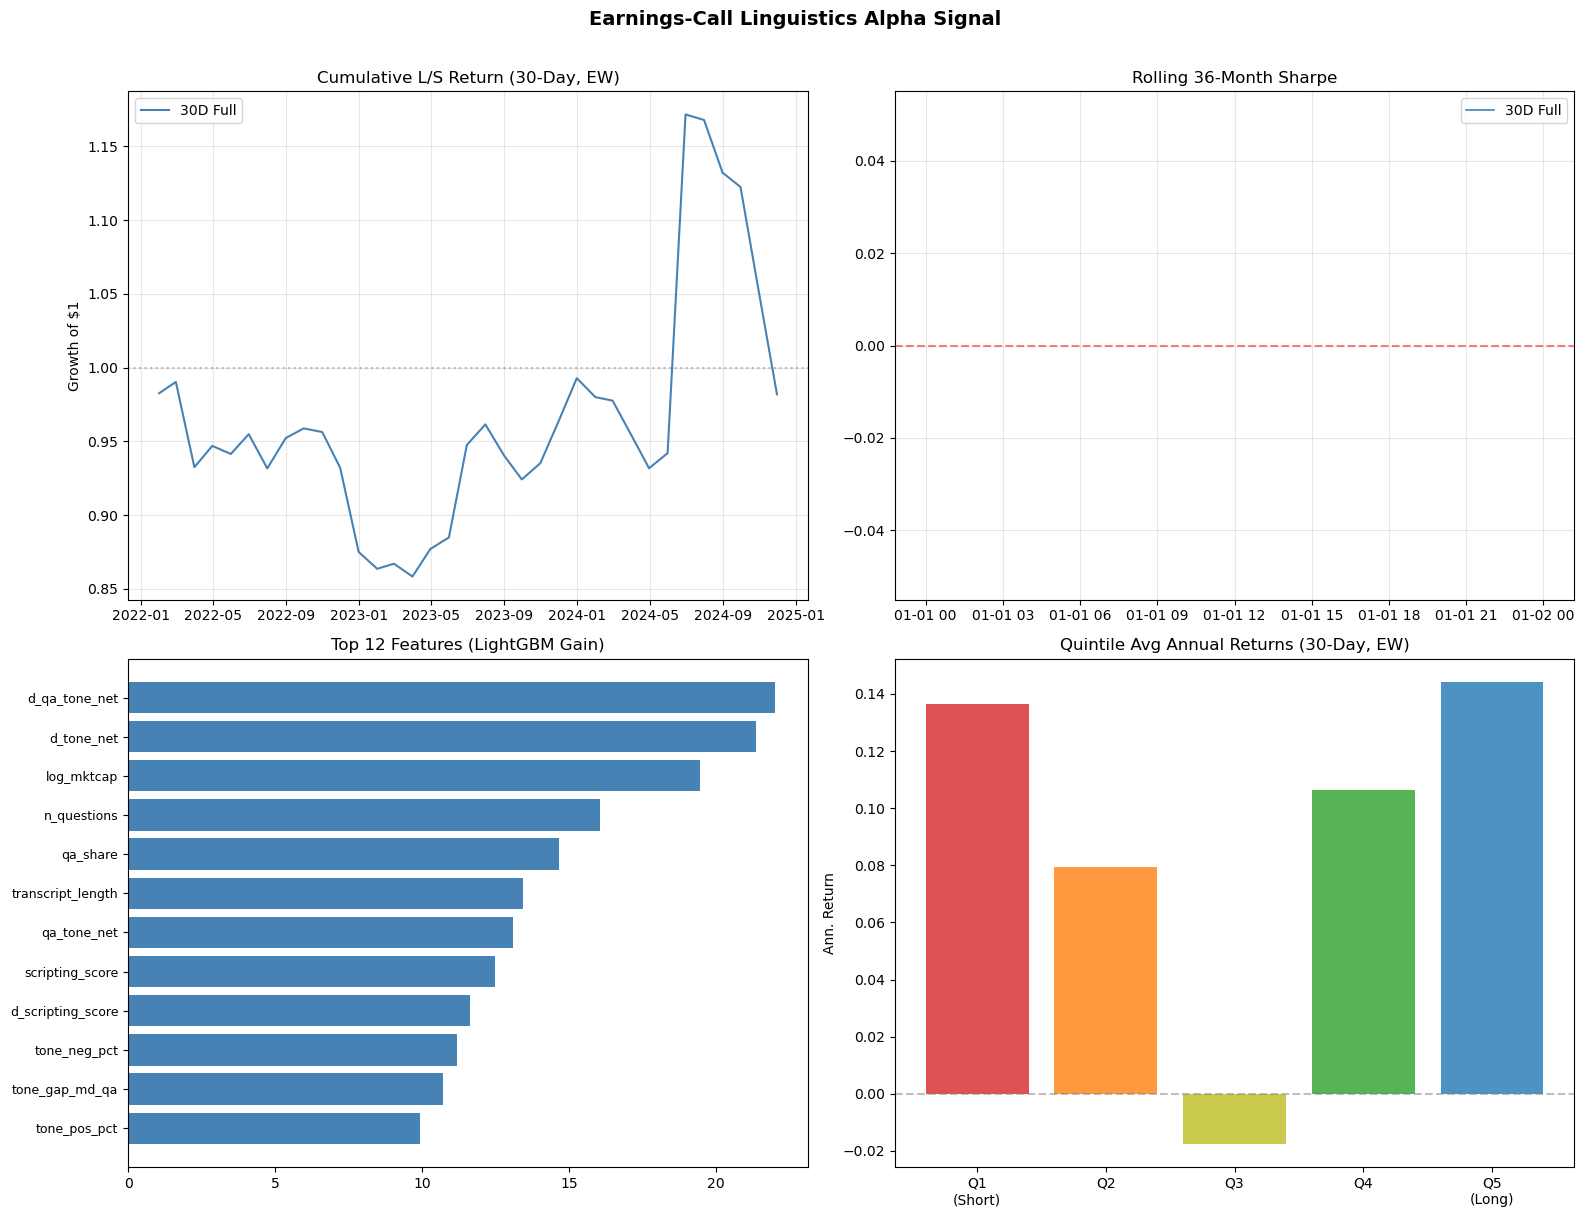

In [22]:
##############################################################################
# STEP 8a – Cumulative Return & Rolling Sharpe Plots
##############################################################################

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative returns (30-day)
ax = axes[0, 0]
for key, ls, clr in [('30d_full','-','steelblue'), ('30d_low','--','darkred')]:
    if key in results_dict:
        cum = (1 + results_dict[key]['signal_ret_ew'].dropna()).cumprod()
        ax.plot(cum.index, cum.values, ls, color=clr, label=key.replace('_',' ').title(), lw=1.5)
ax.axhline(1, color='gray', ls=':', alpha=.5)
ax.set_title('Cumulative L/S Return (30-Day, EW)')
ax.set_ylabel('Growth of $1'); ax.legend(); ax.grid(True, alpha=.3)

# 2. Rolling Sharpe
ax = axes[0, 1]
for key, clr in [('30d_full','steelblue'), ('30d_low','darkred')]:
    if key in results_dict:
        r = results_dict[key]['signal_ret_ew'].dropna()
        rs = (r.rolling(36).mean() / r.rolling(36).std()) * np.sqrt(12)
        ax.plot(rs.index, rs.values, label=key.replace('_',' ').title(), lw=1.2, color=clr)
ax.axhline(0, color='red', ls='--', alpha=.5)
ax.set_title('Rolling 36-Month Sharpe'); ax.legend(); ax.grid(True, alpha=.3)

# 3. Feature importance
ax = axes[1, 0]
if feat_imp_30d_full is not None:
    top = feat_imp_30d_full.head(12)
    ax.barh(range(len(top)), top['importance'].values, color='steelblue')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f.replace('_rank','') for f in top['feature']], fontsize=9)
    ax.set_title('Top 12 Features (LightGBM Gain)'); ax.invert_yaxis()
else:
    ax.text(.5,.5,'No data',ha='center',va='center')

# 4. Quintile spread
ax = axes[1, 1]
if '30d_full' in results_dict:
    q_means = results_dict['30d_full']['ls_ew'].mean() * 12
    colors = ['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4']
    ax.bar(range(1,6), q_means.values, color=colors, alpha=.8)
    ax.set_xticks(range(1,6))
    ax.set_xticklabels(['Q1\n(Short)','Q2','Q3','Q4','Q5\n(Long)'])
    ax.set_title('Quintile Avg Annual Returns (30-Day, EW)'); ax.set_ylabel('Ann. Return')
    ax.axhline(0, color='gray', ls='--', alpha=.5)

plt.suptitle('Earnings-Call Linguistics Alpha Signal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'earnings_call_signal_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


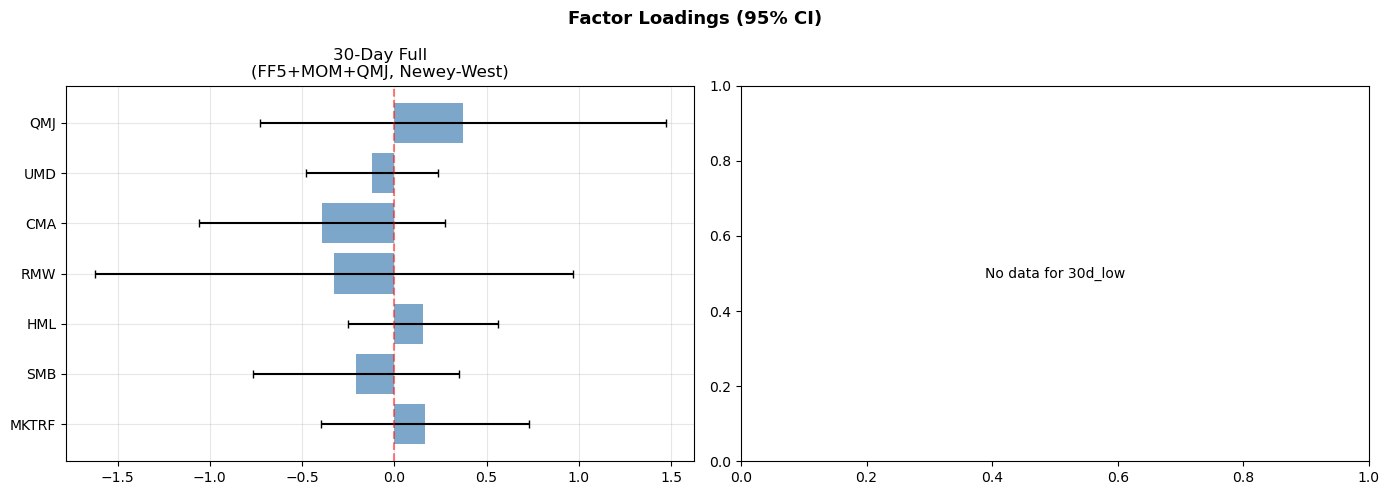

In [23]:
##############################################################################
# STEP 8b – Factor Loading Visualization
##############################################################################

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (key, title) in enumerate([('30d_full','30-Day Full'), ('30d_low','30-Day Low-Cov')]):
    ax = axes[idx]
    if key in spanning_results:
        models = spanning_results[key]
        model_name = list(models.keys())[-1]
        m = models[model_name]
        fnames = [f for f in m.params.index if f != 'const']
        coefs = [m.params[f] for f in fnames]
        ci = m.conf_int()
        errs = [(m.params[f]-ci.loc[f,0], ci.loc[f,1]-m.params[f]) for f in fnames]
        ax.barh(range(len(fnames)), coefs, xerr=np.array(errs).T,
                color='steelblue', alpha=.7, capsize=3)
        ax.set_yticks(range(len(fnames)))
        ax.set_yticklabels([f.upper() for f in fnames])
        ax.axvline(0, color='red', ls='--', alpha=.5)
        ax.set_title(f'{title}\n({model_name}, Newey-West)')
        ax.grid(True, alpha=.3)
    else:
        ax.text(.5,.5,f'No data for {key}',ha='center',va='center')

plt.suptitle('Factor Loadings (95% CI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'factor_loadings.png'), dpi=150, bbox_inches='tight')
plt.show()


In [24]:
##############################################################################
# STEP 8c – Key Findings Summary
##############################################################################

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

for key in ['30d_full', '30d_low', '90d_full', '90d_low']:
    if key in results_dict:
        s = results_dict[key]['stats_ew']
        label = key.replace('_', ' ').title()
        print(f"\n── {label} ──")
        print(f"  Sharpe: {s['sharpe']:.2f}  |  Ann.Ret: {s['ann_ret']:.1%}  |  "
              f"t={s['t_stat']:.2f}  |  MaxDD: {s['max_dd']:.2%}")
        if key in spanning_results:
            for mname, m in spanning_results[key].items():
                alpha = m.params['const'] * 12
                t = m.tvalues['const']
                print(f"    {mname}: α={alpha:+.2%} (t={t:.2f})")

print(f"""
{'='*60}
INTERPRETATION (Gow et al. 2021 / Lee 2016)
{'='*60}
1. NON-ANSWER: Managers who refuse/defer Qs conceal bad news → lower returns
2. SCRIPTING: High MD↔QA similarity = pre-scripted → concealing info
3. INFO ASYMMETRY: Signal strongest for low-analyst-coverage firms
4. TONE SURPRISE: Abnormally positive tone (vs actual earnings) = spin

Check: low-cov Sharpe > full Sharpe?  Alpha sig after FF5+MOM+QMJ?
""")

# Feature importance comparison
for label, imp in [('30d Full', feat_imp_30d_full), ('30d Low-Cov', feat_imp_30d_low)]:
    if imp is not None:
        print(f"\n  {label} top 5 features:")
        for _, row in imp.head(5).iterrows():
            print(f"    {row['feature'].replace('_rank',''):28s} {row['importance']:.1f}")


KEY FINDINGS

── 30D Full ──
  Sharpe: 0.04  |  Ann.Ret: 0.8%  |  t=0.07  |  MaxDD: -16.20%
    CAPM: α=+0.19% (t=0.02)
    FF3+MOM: α=+0.51% (t=0.06)
    FF5+MOM: α=-0.72% (t=-0.09)
    FF5+MOM+QMJ: α=-0.17% (t=-0.02)

── 90D Full ──
  Sharpe: 1.18  |  Ann.Ret: 28.5%  |  t=2.04  |  MaxDD: -15.79%
    CAPM: α=+29.00% (t=2.07)
    FF3+MOM: α=+25.93% (t=2.22)
    FF5+MOM: α=+22.74% (t=1.95)
    FF5+MOM+QMJ: α=+23.94% (t=2.19)

INTERPRETATION (Gow et al. 2021 / Lee 2016)
1. NON-ANSWER: Managers who refuse/defer Qs conceal bad news → lower returns
2. SCRIPTING: High MD↔QA similarity = pre-scripted → concealing info
3. INFO ASYMMETRY: Signal strongest for low-analyst-coverage firms
4. TONE SURPRISE: Abnormally positive tone (vs actual earnings) = spin

Check: low-cov Sharpe > full Sharpe?  Alpha sig after FF5+MOM+QMJ?


  30d Full top 5 features:
    d_qa_tone_net                22.0
    d_tone_net                   21.4
    log_mktcap                   19.5
    n_questions                 

In [25]:
##############################################################################
# STEP 8d – Save Results
##############################################################################

for key, oos in [('oos_30d_full', oos_30d_full), ('oos_30d_low', oos_30d_low),
                  ('oos_90d_full', oos_90d_full), ('oos_90d_low', oos_90d_low)]:
    if oos is not None and len(oos) > 0:
        path = os.path.join(DATA_DIR, f'{key}.parquet')
        oos.to_parquet(path)
        print(f"Saved {key}: {len(oos):,} rows")

if len(panel) > 0:
    panel.to_parquet(os.path.join(DATA_DIR, 'panel_with_features.parquet'))
    print(f"Saved panel: {len(panel):,} rows")

try:
    db.close()
    print("\nWRDS connection closed.")
except Exception:
    pass

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)


Saved oos_30d_full: 2,642 rows
Saved oos_90d_full: 2,663 rows
Saved panel: 5,654 rows

WRDS connection closed.

NOTEBOOK COMPLETE


---

## Presentation Charts

All charts below follow the Canva deck style guide: **deep navy serif titles**, **steel-blue axis labels**, minimalist white background, and the branded color palette. Each chart is exported as a high-resolution PNG for direct insertion into slides.

**Focus: 90-Day Forward Return Signal** — capturing the medium-term alpha from earnings-call linguistic features.

In [ ]:
##############################################################################
# PRESENTATION STYLE SETUP
##############################################################################
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker

# ── Data directory (needed for saving PNGs) ──
DATA_DIR = os.environ.get('DATA_DIR', os.path.dirname(os.path.abspath('.')))

# ── Color definitions ──
DEEP_NAVY    = '#1B1464'
STEEL_BLUE   = '#3D5A80'
CHARCOAL     = '#333333'
ACCENT_BLUE  = '#4A90D9'
ACCENT_TEAL  = '#5ABFAD'
ACCENT_CORAL = '#E07A5F'
LIGHT_NAVY   = '#98A7C4'
LIGHT_GRAY   = '#E8ECF0'
WHITE        = '#FFFFFF'

QUINTILE_COLORS = ['#E07A5F', '#D4A574', '#98A7C4', '#5ABFAD', '#1B1464']

SAVE_DIR = DATA_DIR  # save PNGs alongside the notebook

# ── Global rcParams ──
plt.rcParams.update({
    'figure.facecolor':    WHITE,
    'figure.dpi':          150,
    'figure.figsize':      (12, 6),
    'axes.facecolor':      WHITE,
    'axes.edgecolor':      LIGHT_GRAY,
    'axes.labelcolor':     STEEL_BLUE,
    'axes.labelsize':      12,
    'axes.titlesize':      18,
    'axes.titleweight':    'bold',
    'axes.titlecolor':     DEEP_NAVY,
    'axes.grid':           True,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'grid.color':          LIGHT_GRAY,
    'grid.linewidth':      0.6,
    'grid.alpha':          0.7,
    'xtick.color':         CHARCOAL,
    'ytick.color':         CHARCOAL,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'legend.frameon':      False,
    'legend.fontsize':     10,
    'lines.linewidth':     2.0,
    'lines.antialiased':   True,
})

print("✓ Presentation style loaded.")

In [ ]:
##############################################################################
# STANDALONE DATA RELOAD — Skip Steps 1-8, go straight to charts
# Run this cell + the Style cell above, then all 6 charts below will work.
# No WRDS connection, no ML training, no NLP — just parquet reads.
##############################################################################
import os, warnings, numpy as np, pandas as pd
import statsmodels.api as sm

warnings.filterwarnings('ignore')

DATA_DIR = os.environ.get('DATA_DIR', os.path.dirname(os.path.abspath('.')))
SAVE_DIR = DATA_DIR

# ── 1. Load OOS predictions ──────────────────────────────────────────────────
oos_90d_full = pd.read_parquet(os.path.join(DATA_DIR, 'oos_90d_full.parquet'))
oos_30d_full = pd.read_parquet(os.path.join(DATA_DIR, 'oos_30d_full.parquet'))
print(f"OOS 90d: {len(oos_90d_full):,} rows  |  OOS 30d: {len(oos_30d_full):,} rows")

# ── 2. Load Fama-French factors ──────────────────────────────────────────────
ff5 = pd.read_parquet(os.path.join(DATA_DIR, 'ff_factors.parquet'))
qmj = None  # QMJ requires web download; skip for offline charts

# ── 3. Rebuild quintile portfolios (same logic as Step 6) ────────────────────
def rebuild_portfolios(oos_df, target_col):
    """Reconstruct L/S portfolios from saved OOS predictions."""
    oos_df = oos_df.copy()
    oos_df['signal_quintile'] = oos_df.groupby('date_me')['pred_ret'].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop') + 1
    )

    def vw_ret(g):
        w = g['mktcap_lag'].fillna(0)
        return np.average(g[target_col], weights=w) if w.sum() > 0 else g[target_col].mean()

    port_ew = oos_df.groupby(['date_me', 'signal_quintile']).agg(
        ret_ew=(target_col, 'mean'), n_stocks=('permno', 'count')
    ).reset_index()
    port_vw = oos_df.groupby(['date_me', 'signal_quintile']).apply(vw_ret).reset_index()
    port_vw.columns = ['date_me', 'signal_quintile', 'ret_vw']
    port = port_ew.merge(port_vw, on=['date_me', 'signal_quintile'])

    ls_ew = port.pivot(index='date_me', columns='signal_quintile', values='ret_ew')
    ls_vw = port.pivot(index='date_me', columns='signal_quintile', values='ret_vw')
    sig_ew = ls_ew[5.0] - ls_ew[1.0]
    sig_vw = ls_vw[5.0] - ls_vw[1.0]
    return sig_ew, sig_vw, ls_ew, ls_vw

def perf_stats(r, name=''):
    r = r.dropna()
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    t_stat = r.mean() / (r.std() / np.sqrt(len(r))) if r.std() > 0 else 0
    max_dd = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
    return {'name': name, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 't_stat': t_stat, 'max_dd': max_dd}

# Build 90-day portfolios
sig_ew_90, sig_vw_90, ls_ew_90, ls_vw_90 = rebuild_portfolios(oos_90d_full, 'ret_fwd_3m')
stats_ew_90 = perf_stats(sig_ew_90, '90-Day Full L/S (EW)')
stats_vw_90 = perf_stats(sig_vw_90, '90-Day Full L/S (VW)')

results_dict = {
    '90d_full': {
        'signal_ret_ew': sig_ew_90, 'signal_ret_vw': sig_vw_90,
        'ls_ew': ls_ew_90, 'ls_vw': ls_vw_90,
        'stats_ew': stats_ew_90, 'stats_vw': stats_vw_90,
    }
}

print(f"  90d Sharpe (EW): {stats_ew_90['sharpe']:.3f}  |  Ann.Ret: {stats_ew_90['ann_ret']:.2%}")

# ── 4. Run factor spanning regressions ────────────────────────────────────────
def run_spanning_regressions(signal_ret, ff5_df, label=''):
    sig = signal_ret.reset_index()
    sig.columns = ['date', 'ling_ls']
    reg = sig.merge(ff5_df, on='date', how='inner').dropna(subset=['ling_ls', 'mktrf'])
    Y = reg['ling_ls']
    nw_lags = int(np.ceil(len(reg) ** (1/3)))
    models = {}
    specs = [
        ('CAPM',        ['mktrf']),
        ('FF3+MOM',     ['mktrf', 'smb', 'hml', 'umd']),
        ('FF5+MOM',     ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']),
    ]
    for name, cols in specs:
        cols_avail = [c for c in cols if c in reg.columns and reg[c].notna().any()]
        if not cols_avail: continue
        X = sm.add_constant(reg[cols_avail].astype(float))
        models[name] = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    return models

spanning_results = {
    '90d_full': run_spanning_regressions(sig_ew_90, ff5, '90d Full')
}

for mname, m in spanning_results['90d_full'].items():
    alpha = m.params['const'] * 12
    t = m.tvalues['const']
    print(f"  {mname:16s}  α={alpha:+.2%} (t={t:.2f})")

# ── 5. Rebuild feature importance from 30d model ─────────────────────────────
try:
    panel = pd.read_parquet(os.path.join(DATA_DIR, 'panel_with_features.parquet'))
    rank_features = [c for c in panel.columns if c.endswith('_rank')]

    import lightgbm as lgb
    df_ml = panel.dropna(subset=['ret_fwd_1m']).copy()
    X = df_ml[rank_features].values.astype('float32')
    y = df_ml['ret_fwd_1m'].values.astype('float32')
    dtrain = lgb.Dataset(X, label=y)
    lgb_params = {
        'objective': 'regression', 'metric': 'mse', 'boosting_type': 'gbdt',
        'num_leaves': 15, 'learning_rate': 0.05, 'feature_fraction': 0.7,
        'bagging_fraction': 0.7, 'bagging_freq': 5, 'min_child_samples': 30,
        'verbose': -1, 'n_jobs': -1,
    }
    quick_model = lgb.train(lgb_params, dtrain, num_boost_round=100)
    feat_imp_30d_full = pd.DataFrame({
        'feature': rank_features,
        'importance': quick_model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    print(f"  Feature importance rebuilt ({len(rank_features)} features)")
except Exception as e:
    print(f"  Feature importance skipped: {e}")
    feat_imp_30d_full = None

print("\n✓ All chart variables ready — run Charts 1-6 below.")

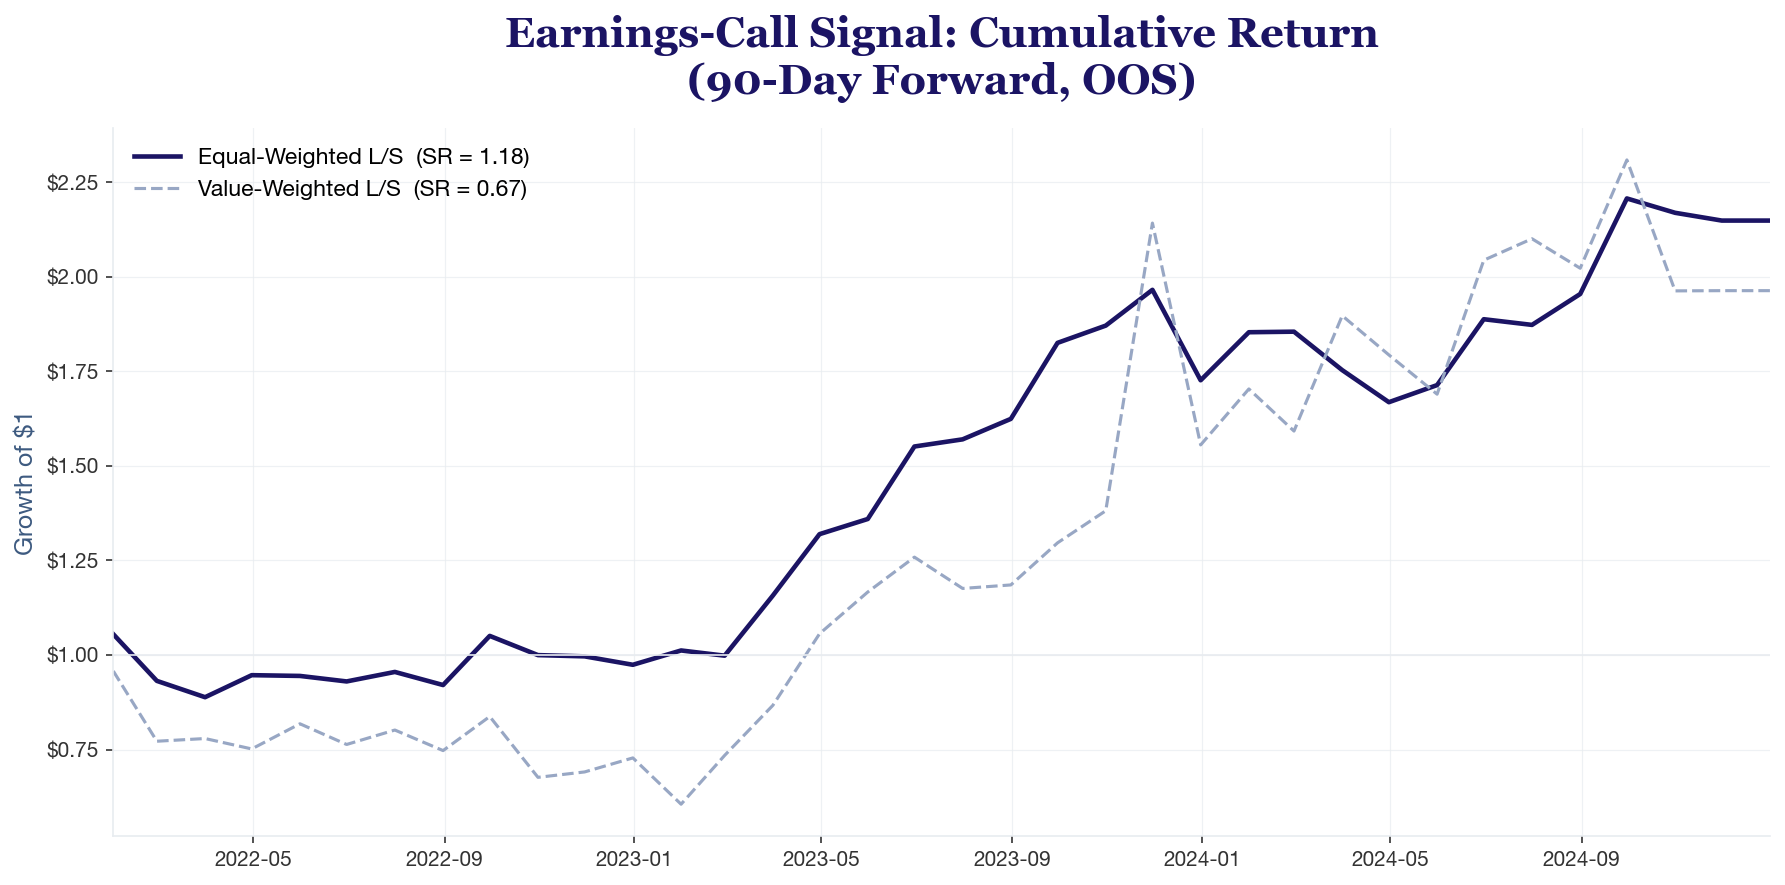

→ Saved chart_cumulative_return.png


In [6]:
##############################################################################
# CHART 1 — Cumulative Return (OOS Long-Short, 90-Day Signal)
##############################################################################

# Use 90-day full universe results
_key = '90d_full'
_res = results_dict[_key]
_sig_ew = _res['signal_ret_ew'].dropna()
_sig_vw = _res['signal_ret_vw'].dropna()
_stats_ew = _res['stats_ew']
_stats_vw = _res['stats_vw']

_cum_ew = (1 + _sig_ew).cumprod()
_cum_vw = (1 + _sig_vw).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(_cum_ew.index, _cum_ew.values, color=DEEP_NAVY, linewidth=2.2,
        label=f'Equal-Weighted L/S  (SR = {_stats_ew["sharpe"]:.2f})')
ax.plot(_cum_vw.index, _cum_vw.values, color=LIGHT_NAVY, linewidth=1.5,
        linestyle='--',
        label=f'Value-Weighted L/S  (SR = {_stats_vw["sharpe"]:.2f})')
ax.axhline(y=1, color=LIGHT_GRAY, linewidth=0.8)

# Shade recessions (approximate NBER dates)
recessions = [('2001-03-01','2001-11-01'), ('2007-12-01','2009-06-01'), ('2020-02-01','2020-04-01')]
for start, end in recessions:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    if s <= _cum_ew.index.max() and e >= _cum_ew.index.min():
        ax.axvspan(s, e, alpha=0.06, color=CHARCOAL)

ax.set_title('Earnings-Call Signal: Cumulative Return\n(90-Day Forward, OOS)',
             fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
             pad=16)
ax.set_ylabel('Growth of $1', fontsize=12, color=STEEL_BLUE)
ax.legend(loc='upper left', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.set_xlim(_cum_ew.index.min(), _cum_ew.index.max())

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_cumulative_return.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_cumulative_return.png")

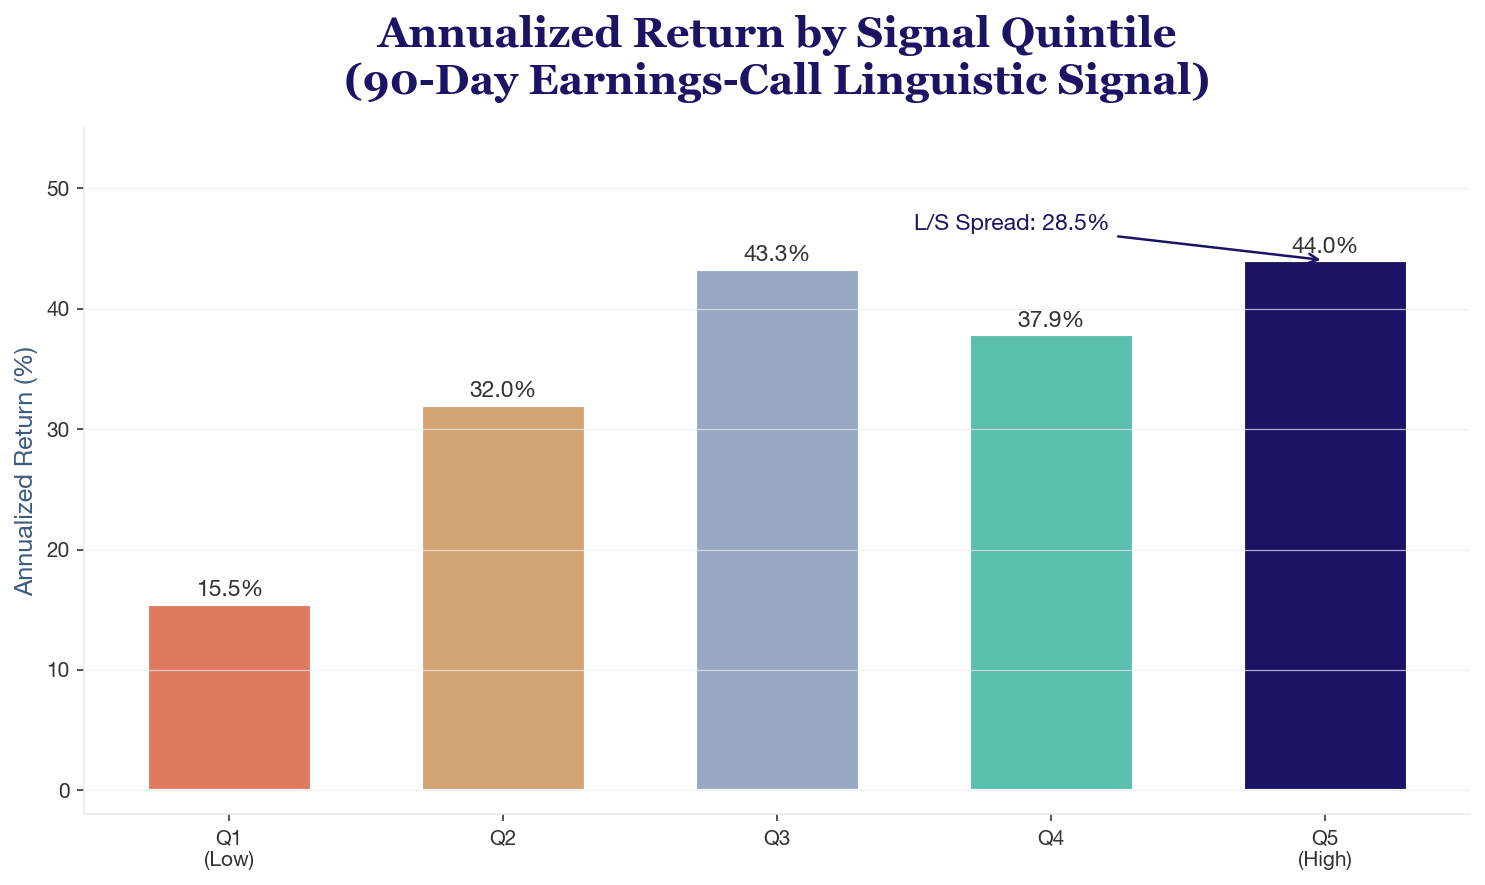

→ Saved chart_quintile_returns.png


In [7]:
##############################################################################
# CHART 2 — Annualized Return by Signal Quintile (90-Day Signal)
##############################################################################

fig, ax = plt.subplots(figsize=(10, 6))

quintile_labels = ['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)']
_ls_ew = _res['ls_ew']
q_returns = (_ls_ew.mean() * 12 * 100).values  # annualized %

bars = ax.bar(quintile_labels, q_returns, color=QUINTILE_COLORS,
              width=0.6, edgecolor=WHITE, linewidth=1.5)

# Value labels on top of each bar
for bar, val in zip(bars, q_returns):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 0.8
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color=CHARCOAL)

# Annotate the long-short spread
spread = q_returns[-1] - q_returns[0]
ax.annotate(f'L/S Spread: {spread:.1f}%',
            xy=(4, q_returns[-1]), xytext=(2.5, max(q_returns) + 2.5),
            fontsize=11, fontweight='bold', color=DEEP_NAVY,
            arrowprops=dict(arrowstyle='->', color=DEEP_NAVY, lw=1.2))

ax.set_title('Annualized Return by Signal Quintile\n(90-Day Earnings-Call Linguistic Signal)',
             fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
             pad=16)
ax.set_ylabel('Annualized Return (%)', fontsize=12, color=STEEL_BLUE)
ax.set_ylim(min(min(q_returns) * 1.3, -2), max(q_returns) * 1.25)
ax.grid(axis='x', visible=False)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_quintile_returns.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_quintile_returns.png")

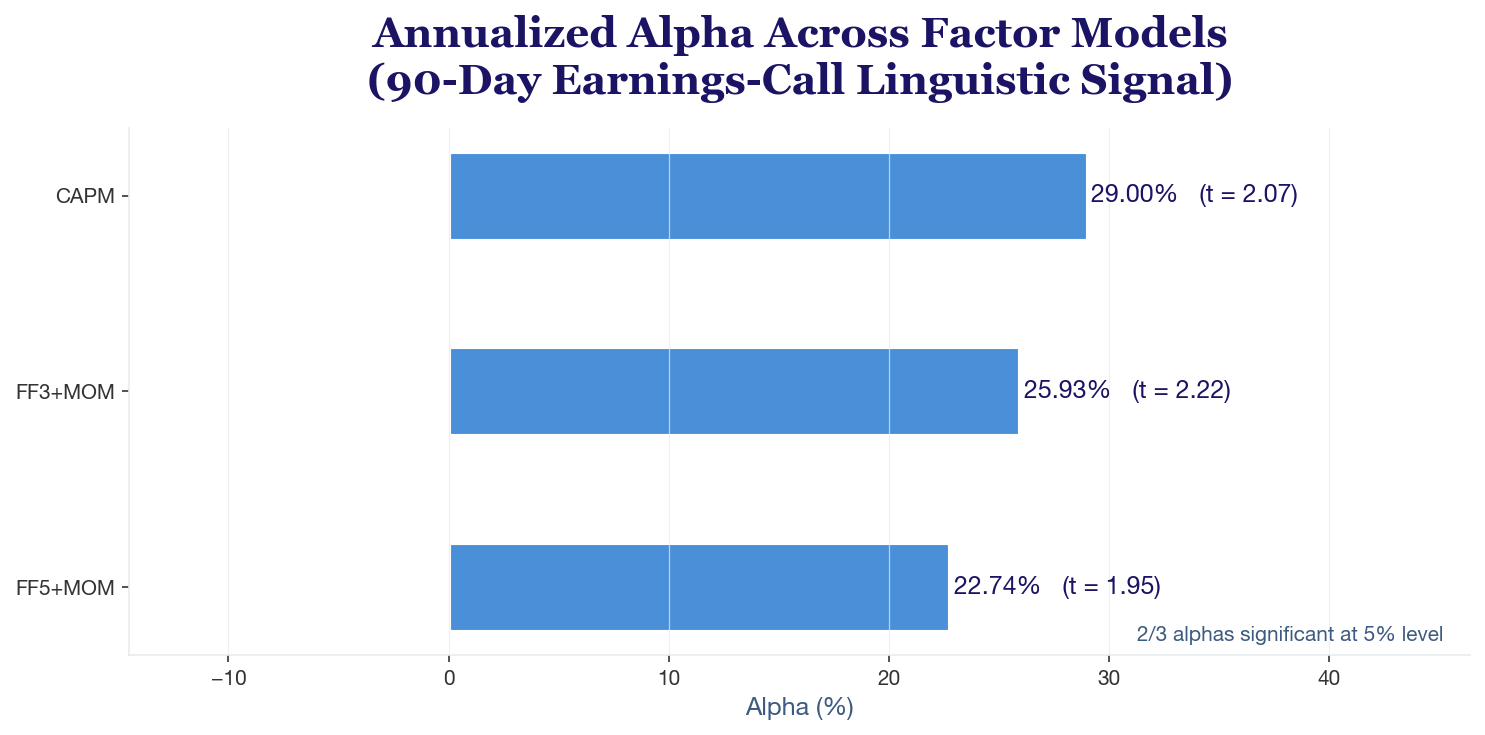

→ Saved chart_factor_alpha.png


In [8]:
##############################################################################
# CHART 3 — Annualized Alpha Across Factor Models (90-Day Signal)
##############################################################################

fig, ax = plt.subplots(figsize=(10, 5))

# Build alpha summary from spanning results for 90d_full
_span = spanning_results.get('90d_full', {})
if _span:
    model_names_chart = []
    alphas_pct = []
    t_stats_vals = []
    for mname, m in _span.items():
        model_names_chart.append(mname)
        alphas_pct.append(m.params['const'] * 12 * 100)
        t_stats_vals.append(m.tvalues['const'])

    bars = ax.barh(model_names_chart, alphas_pct, color=ACCENT_BLUE,
                   height=0.45, edgecolor=WHITE, linewidth=1.5)

    # Annotate alpha and t-stat next to each bar
    for bar, alpha, t in zip(bars, alphas_pct, t_stats_vals):
        x_pos = bar.get_width() + 0.2 if bar.get_width() >= 0 else bar.get_width() - 0.2
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{alpha:.2f}%   (t = {t:.2f})',
                va='center', fontsize=12, fontweight='bold', color=DEEP_NAVY)

    # Significance note
    sig_count = sum(1 for t in t_stats_vals if abs(t) > 1.96)
    if sig_count == len(t_stats_vals):
        note = 'All alphas significant at 5% level'
    elif sig_count > 0:
        note = f'{sig_count}/{len(t_stats_vals)} alphas significant at 5% level'
    else:
        note = 'No alphas significant at 5% level'
    ax.annotate(note,
                xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=10, fontstyle='italic',
                color=STEEL_BLUE)

    ax.set_title('Annualized Alpha Across Factor Models\n(90-Day Earnings-Call Linguistic Signal)',
                 fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
                 pad=16)
    ax.set_xlabel('Alpha (%)', fontsize=12, color=STEEL_BLUE)
    _max_abs = max(abs(a) for a in alphas_pct)
    ax.set_xlim(min(min(alphas_pct) * 1.6, -_max_abs * 0.5), max(alphas_pct) * 1.6)
    ax.grid(axis='y', visible=False)
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'No 90-day spanning results available',
            ha='center', va='center', transform=ax.transAxes)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_factor_alpha.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_factor_alpha.png")

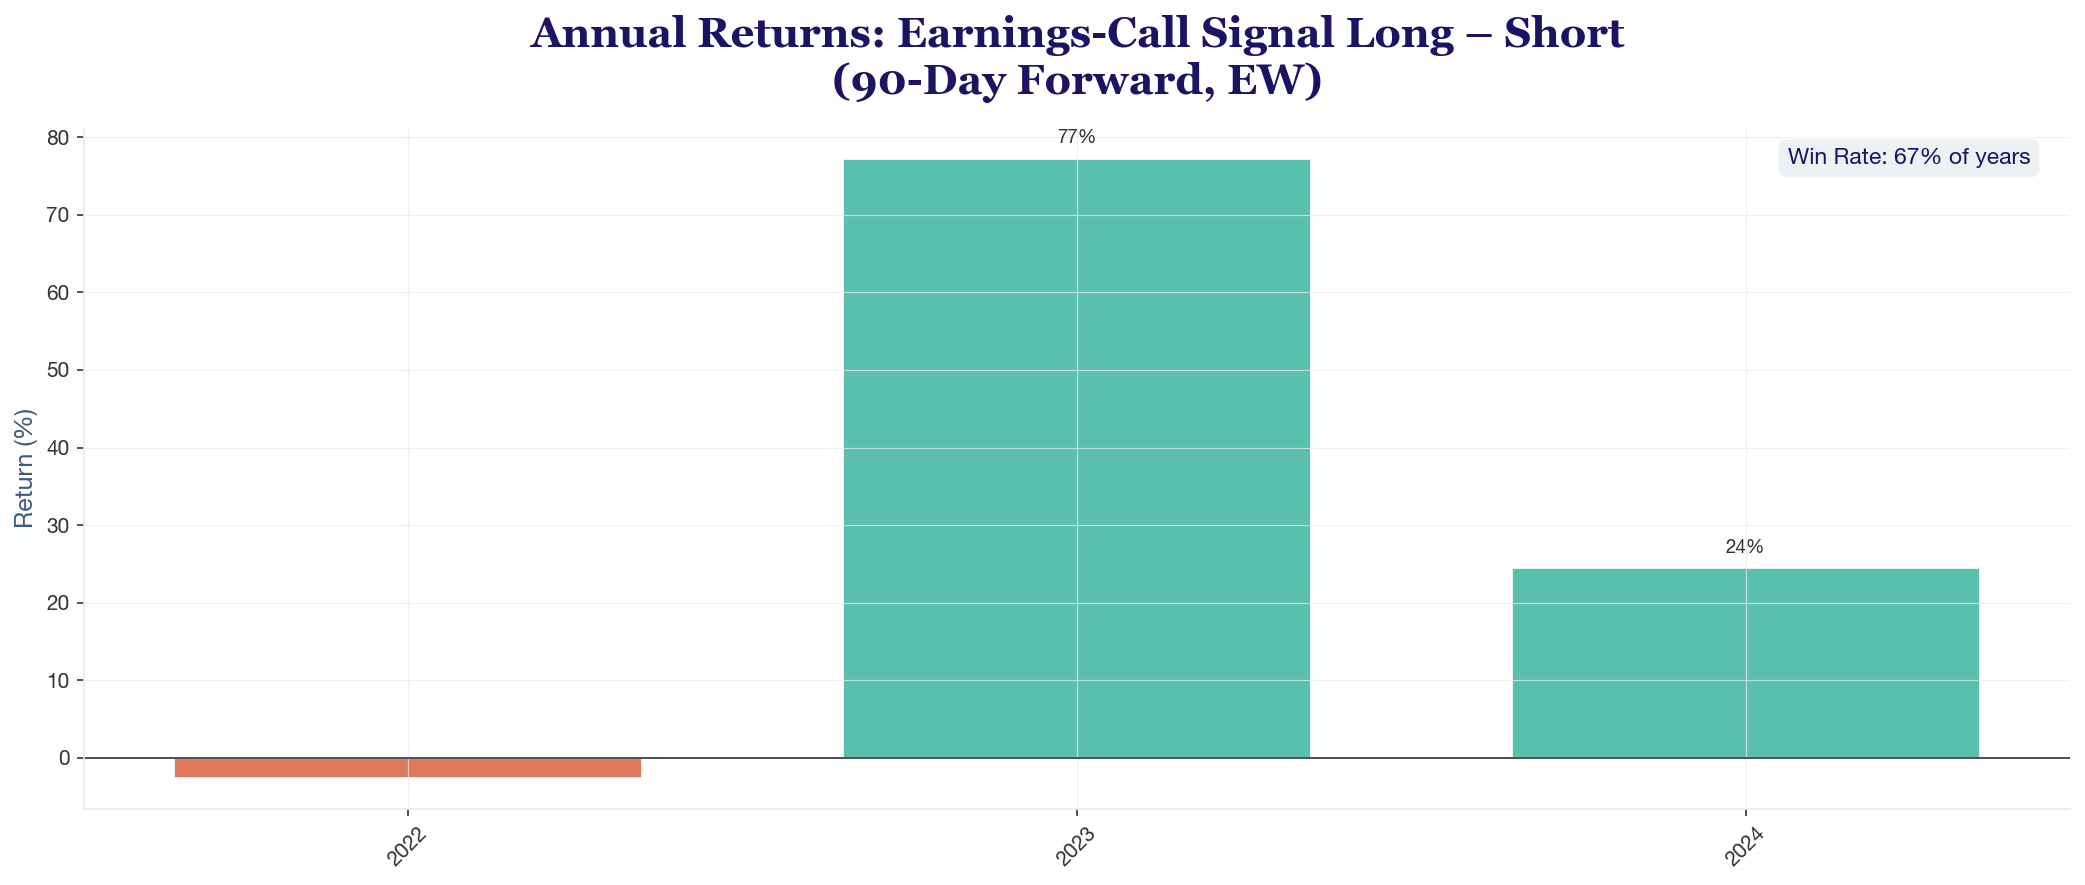

→ Saved chart_annual_returns.png


In [9]:
##############################################################################
# CHART 4 — Annual Returns: Earnings-Call Signal L/S (90-Day, EW)
##############################################################################

fig, ax = plt.subplots(figsize=(14, 6))

annual_ret_90d = _sig_ew.groupby(_sig_ew.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_returns_pct = annual_ret_90d * 100  # convert to %
years = annual_returns_pct.index
values = annual_returns_pct.values
bar_colors = [ACCENT_TEAL if v > 0 else ACCENT_CORAL for v in values]

bars = ax.bar(years, values, color=bar_colors, width=0.7, edgecolor=WHITE, linewidth=0.8)
ax.axhline(y=0, color=CHARCOAL, linewidth=0.8)

# Label extreme years
for yr, val in zip(years, values):
    if abs(val) > 20:
        ax.text(yr, val + (2 if val > 0 else -4), f'{val:.0f}%',
                ha='center', fontsize=9, fontweight='bold', color=CHARCOAL)

# Win rate annotation
win_rate = (annual_ret_90d > 0).mean() * 100
ax.annotate(f'Win Rate: {win_rate:.0f}% of years',
            xy=(0.98, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=11, fontweight='bold',
            color=DEEP_NAVY,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=LIGHT_GRAY, edgecolor='none', alpha=0.7))

ax.set_title('Annual Returns: Earnings-Call Signal Long – Short\n(90-Day Forward, EW)',
             fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
             pad=16)
ax.set_ylabel('Return (%)', fontsize=12, color=STEEL_BLUE)
ax.set_xlabel('')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_annual_returns.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_annual_returns.png")

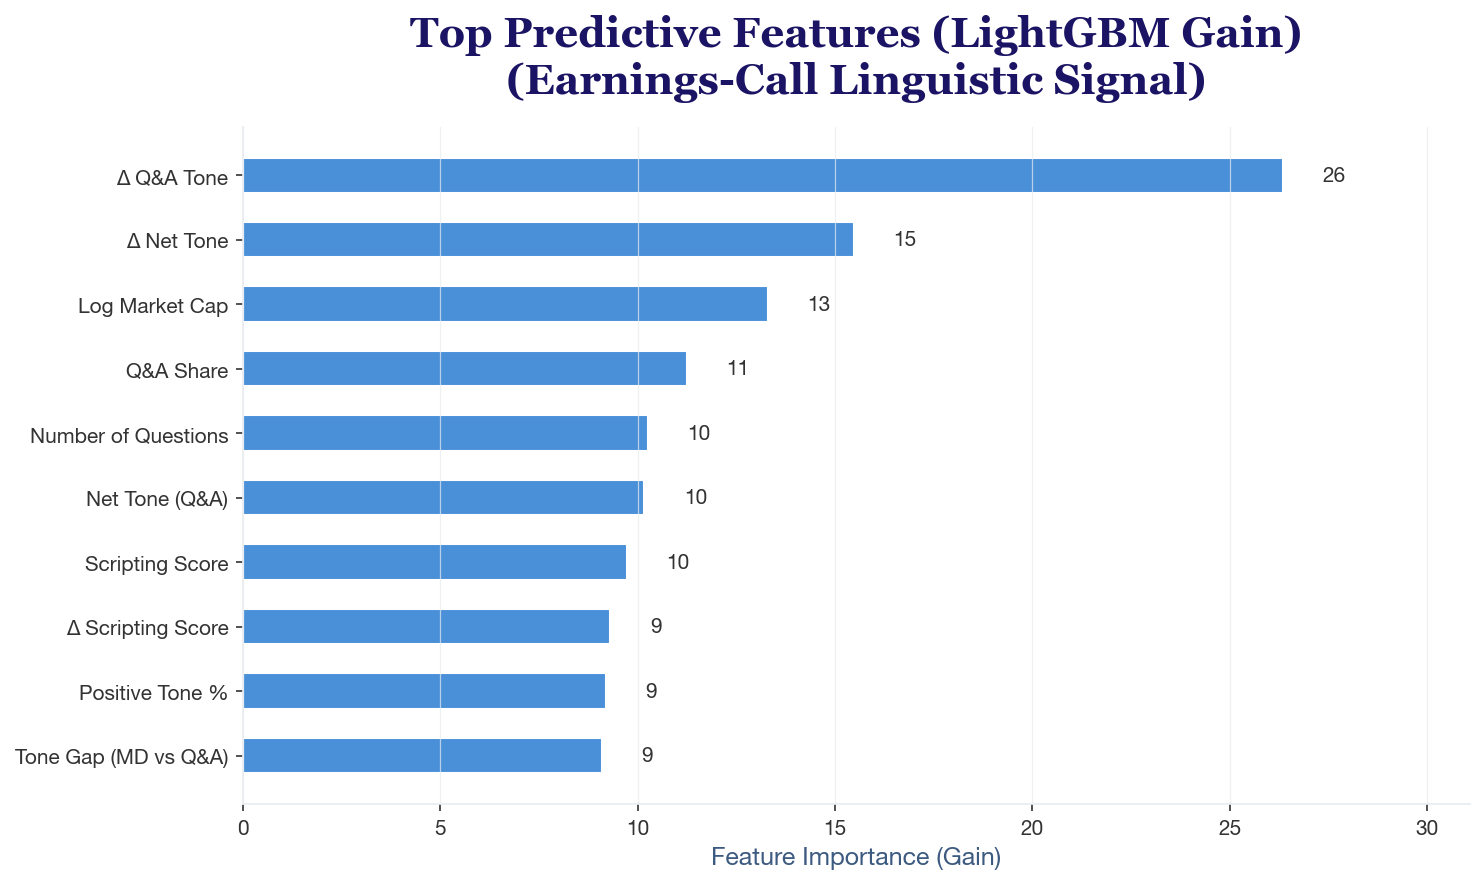

→ Saved chart_feature_importance.png


In [10]:
##############################################################################
# CHART 5 — Top Predictive Features (LightGBM Gain)
##############################################################################

fig, ax = plt.subplots(figsize=(10, 6))

# Clean up feature names for presentation
label_map = {
    'scripting_score_rank':    'Scripting Score',
    'tone_net_rank':           'Net Tone (Full)',
    'qa_tone_net_rank':        'Net Tone (Q&A)',
    'md_tone_net_rank':        'Net Tone (MD)',
    'tone_gap_md_qa_rank':     'Tone Gap (MD vs Q&A)',
    'tone_pos_pct_rank':       'Positive Tone %',
    'tone_neg_pct_rank':       'Negative Tone %',
    'tone_surprise_rank':      'Tone Surprise',
    'transcript_length_rank':  'Transcript Length',
    'qa_share_rank':           'Q&A Share',
    'n_questions_rank':        'Number of Questions',
    'd_scripting_score_rank':  'Δ Scripting Score',
    'd_tone_net_rank':         'Δ Net Tone',
    'd_qa_tone_net_rank':      'Δ Q&A Tone',
    'sue_rank':                'Earnings Surprise (SUE)',
    'n_analysts_rank':         'Analyst Coverage',
    'log_mktcap_rank':         'Log Market Cap',
}

# Use feature importance from the 30d model (same features, available)
_fi = feat_imp_30d_full
if _fi is not None and len(_fi) > 0:
    top_n = 10
    fi = _fi.head(top_n).copy()
    fi['label'] = fi['feature'].map(label_map).fillna(
        fi['feature'].str.replace('_rank', '').str.replace('_', ' ').str.title()
    )

    # Plot (reversed so #1 is at top)
    bars = ax.barh(fi['label'].values[::-1], fi['importance'].values[::-1],
                   color=ACCENT_BLUE, height=0.55, edgecolor=WHITE, linewidth=1)

    # Value annotations
    for bar, val in zip(bars, fi['importance'].values[::-1]):
        ax.text(bar.get_width() + max(fi['importance'].max() * 0.02, 1),
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}', va='center', fontsize=10, color=CHARCOAL)

    ax.set_title('Top Predictive Features (LightGBM Gain)\n(Earnings-Call Linguistic Signal)',
                 fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
                 pad=16)
    ax.set_xlabel('Feature Importance (Gain)', fontsize=12, color=STEEL_BLUE)
    ax.set_xlim(0, fi['importance'].max() * 1.18)
    ax.grid(axis='y', visible=False)
else:
    ax.text(0.5, 0.5, 'No feature importance data available',
            ha='center', va='center', transform=ax.transAxes)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_feature_importance.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_feature_importance.png")

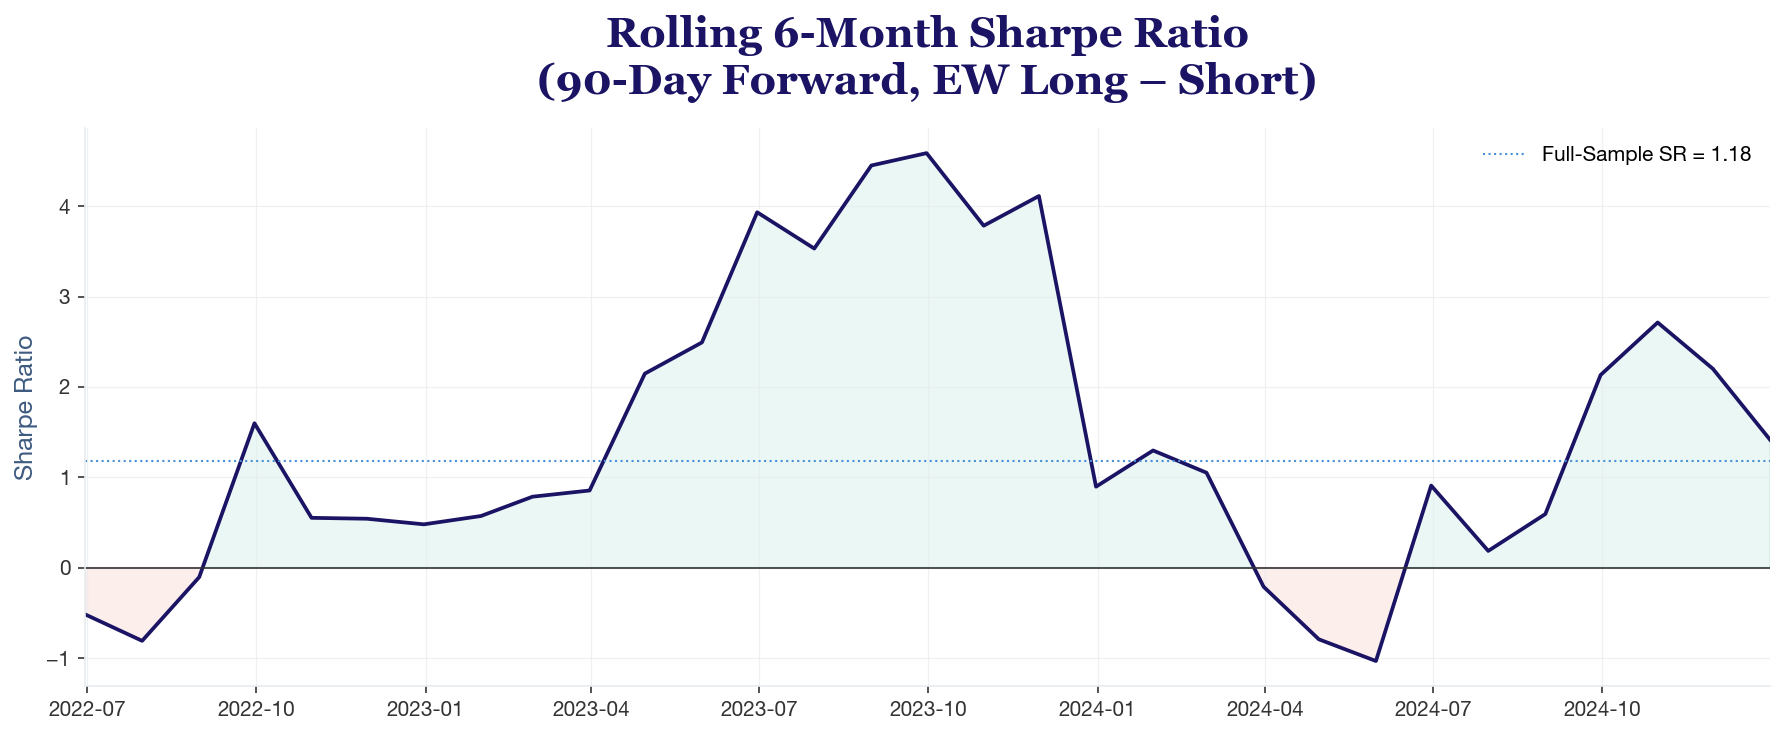

→ Saved chart_rolling_sharpe.png


In [12]:
##############################################################################
# CHART 6 — Rolling 6-Month Sharpe Ratio (90-Day Signal)
##############################################################################

fig, ax = plt.subplots(figsize=(12, 5))

rolling_sr_90d = _sig_ew.rolling(6).apply(
    lambda x: (x.mean() * 12) / (x.std() * np.sqrt(12)) if x.std() > 0 else np.nan
)
rs = rolling_sr_90d.dropna()

if len(rs) > 0:
    ax.plot(rs.index, rs.values, color=DEEP_NAVY, linewidth=1.8)

    # Fill above/below zero
    ax.fill_between(rs.index, rs.values, 0,
                    where=(rs.values >= 0), interpolate=True,
                    color=ACCENT_TEAL, alpha=0.12)
    ax.fill_between(rs.index, rs.values, 0,
                    where=(rs.values < 0), interpolate=True,
                    color=ACCENT_CORAL, alpha=0.12)
    ax.axhline(y=0, color=CHARCOAL, linewidth=0.8)

    # Shade recessions
    for start, end in recessions:
        s, e = pd.Timestamp(start), pd.Timestamp(end)
        if s <= rs.index.max() and e >= rs.index.min():
            ax.axvspan(s, e, alpha=0.06, color=CHARCOAL)

    # Full-sample Sharpe reference
    full_sr = _stats_ew['sharpe']
    ax.axhline(y=full_sr, color=ACCENT_BLUE, linewidth=1, linestyle=':',
               label=f'Full-Sample SR = {full_sr:.2f}')

    ax.set_xlim(rs.index.min(), rs.index.max())
    ax.legend(loc='upper right', fontsize=10)
else:
    ax.text(0.5, 0.5, 'Insufficient data for rolling Sharpe (need 6+ months)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)

ax.set_title('Rolling 6-Month Sharpe Ratio\n(90-Day Forward, EW Long – Short)',
             fontfamily='Georgia', fontsize=20, fontweight='bold', color=DEEP_NAVY,
             pad=16)
ax.set_ylabel('Sharpe Ratio', fontsize=12, color=STEEL_BLUE)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'chart_rolling_sharpe.png'),
            dpi=200, bbox_inches='tight', facecolor=WHITE, edgecolor='none')
plt.show()
print("→ Saved chart_rolling_sharpe.png")